In [ ]:
%%html
<style>

::-webkit-scrollbar {
  width: 20px;
  height: 20px;
}
::-webkit-scrollbar-track {
  background-color: transparent;
}
::-webkit-scrollbar-button {
  display: none;
  width: 0;
  height: 0;
}
::-webkit-scrollbar-thumb {
  background-color: #d6dee1;
  border-radius: 20px;
  border: 6px solid transparent;
  background-clip: content-box;
}
::-webkit-scrollbar-thumb:hover {
  background-color: #a8bbbf;
}
* {
  scrollbar-width: thin;
  scrollbar-color: #d6dee1 transparent;
}
</style>

# Headways Analysis

In [1]:
# First we import the requested modules
import json
import math

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

pio.templates.default = "plotly_white"
pd.set_option("display.precision", 3)


import multiprocessing

from pandarallel import pandarallel

num_cores = multiprocessing.cpu_count()
pandarallel.initialize()

INFO: Pandarallel will run on 16 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [2]:
# Available colors
colors = [
    "#1f77b4",  # muted blue
    "#ff7f0e",  # safety orange
    "#2ca02c",  # cooked asparagus green
    "#d62728",  # brick red
    "#9467bd",  # muted purple
    "#8c564b",  # chestnut brown
    "#e377c2",  # raspberry yogurt pink
    "#7f7f7f",  # middle gray
    "#bcbd22",  # curry yellow-green
    "#17becf",  # blue-teal
]

In [3]:
path = "../Data/Raw/"

In [4]:
# WE LOAD THE STOPS AND LINES
with open("../Data/Static/lines_dict.json") as f:
    lines_dict = json.load(f)

## Headways

In [5]:
# Day types
day_type_dict = {  # 0 = Monday, 1 = Tuesday ...
    "LA": [0, 1, 2, 3, 4],  # LABORABLES
    "LJ": [0, 1, 2, 3],  # LUNES A JUEVES
    "VV": [4],  # VIERNES
    "SA": [5],  # SABADOS
    "FE": [6],  # DOMIGOS O FESTIVOS
}

In [6]:
# Headways data — loaded from the live SQLite telemetry engine (Data/runtime/transit_telemetry.db)
import os
import sys

nb_dir = os.getcwd()
repo_root = os.path.abspath(os.path.join(nb_dir, "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from core import db

headways = db.get_all_headways_df("London", None, limit=100_000)
headways = headways[
    ["line", "direction", "datetime", "hw_pos", "busA", "busB", "headway", "busB_ttls"]
].copy()
# Coerce dtypes to mirror the original headways.csv schema
headways["line"] = headways["line"].astype("uint16")
headways["direction"] = headways["direction"].astype("uint16")
headways["hw_pos"] = headways["hw_pos"].astype("uint16")
headways["headway"] = headways["headway"].astype("int16")
headways["busB_ttls"] = headways["busB_ttls"].astype("uint16")
headways["datetime"] = pd.to_datetime(headways["datetime"], format="ISO8601")

In [7]:
headways["datetime"] = pd.to_datetime(headways["datetime"], format="ISO8601")

In [8]:
headways.head()

,line,direction,datetime,hw_pos,busA,busB,headway,busB_ttls
0,18,1,2026-08-18 11:41:05.615133,1,LF75OPR,LF75ONW,45,273
1,18,1,2026-08-18 11:41:05.615133,2,LF75ONW,LF75OOA,63,336
2,18,1,2026-08-18 11:41:05.615133,3,LF75OOA,LF75OPA,818,1154
3,18,2,2026-08-18 11:41:05.615133,1,LF75OPT,LF75OOU,773,1282
4,18,2,2026-08-18 11:41:05.615133,2,LF75OOU,LF75ONU,106,1388


In [9]:
headways.info()

<class 'pandas.DataFrame'>
RangeIndex: 60032 entries, 0 to 60031
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   line       60032 non-null  uint16        
 1   direction  60032 non-null  uint16        
 2   datetime   60032 non-null  datetime64[us]
 3   hw_pos     60032 non-null  uint16        
 4   busA       60032 non-null  object        
 5   busB       60032 non-null  object        
 6   headway    60032 non-null  int16         
 7   busB_ttls  60032 non-null  uint16        
dtypes: datetime64[us](1), int16(1), object(2), uint16(4)
memory usage: 1.9+ MB


In [10]:
headways[(headways.busA == "BF67GLJ") & (headways.busB == "LJ66TRZ")]

,line,direction,datetime,hw_pos,busA,busB,headway,busB_ttls


## Headways Analysis

In [11]:
from statistics import mean

import pylab
import statsmodels.api as sm
from numpy import cos, pi, sin
from scipy import stats
from scipy.spatial.distance import mahalanobis
from scipy.stats.distributions import chi2

In [12]:
# FUNCTIONS
def headways_2d(df):
    times, busesA, busesB, busesC, h12, h23 = [], [], [], [], [], []
    burst_times = df.datetime.unique()
    for burst_time in burst_times:
        time_df1 = df.loc[(df.datetime == burst_time) & (df.direction == 1)]
        time_df2 = df.loc[(df.datetime == burst_time) & (df.direction == 2)]

        for i in range(max(time_df1.shape[0], time_df2.shape[0])):
            if i < (time_df1.shape[0] - 1):
                times.append(burst_time)
                busesA.append(time_df1.iloc[i].busA)
                busesB.append(time_df1.iloc[i].busB)
                busesC.append(time_df1.iloc[i + 1].busB)
                h12.append(time_df1.iloc[i].headway)
                h23.append(time_df1.iloc[i + 1].headway)
            if i < (time_df2.shape[0] - 1):
                times.append(burst_time)
                busesA.append(time_df2.iloc[i].busA)
                busesB.append(time_df2.iloc[i].busB)
                busesC.append(time_df2.iloc[i + 1].busB)
                h12.append(time_df2.iloc[i].headway)
                h23.append(time_df2.iloc[i + 1].headway)

    return pd.DataFrame(
        {"time": times, "busA": busesA, "busB": busesB, "busC": busesC, "h12": h12, "h23": h23}
    )


def conf_ellipse_params(mus, cov_matrix, conf):
    col1 = df["hw12"]
    col2 = df["hw23"]

    # Mean values for the center of the ellipse
    mu1 = col1.mean()
    mu2 = col2.mean()
    mus = [mu1, mu2]

    # Columns covariance matrix
    cov_mat = np.stack((col1, col2), axis=0)
    cov_matrix = np.cov(cov_mat)

    a = cov_matrix[0][0]
    b = cov_matrix[0][1]
    c = cov_matrix[1][1]

    lambda1 = (a + c) / 2 + math.sqrt(((a - c) / 2) ** 2 + b**2)
    lambda2 = (a + c) / 2 - math.sqrt(((a - c) / 2) ** 2 + b**2)

    # Rotation angle
    if (b == 0) and (a >= c):
        theta = 0
    elif (b == 0) and (a < c):
        theta = math.pi / 2
    else:
        theta = math.atan2(lambda1 - a, b)

    # Eigenvectors
    ei_vecs = [[math.cos(theta), -math.sin(theta)], [math.sin(theta), math.cos(theta)]]

    # Chi-Value for desired confidence
    chi_val = chi2.ppf(conf, df=2)

    # Eigenvalues
    r1 = math.sqrt(chi_val * lambda1)
    r2 = math.sqrt(chi_val * lambda2)
    ei_vals = [r1, r2]

    return mus, ei_vecs, ei_vals


# Get N equiespaciated points of the ellipse
def ellipse(mus, cov_matrix, conf):
    a = cov_matrix[0][0]
    b = cov_matrix[0][1]
    c = cov_matrix[1][1]

    lambda1 = (a + c) / 2 + math.sqrt(((a - c) / 2) ** 2 + b**2)
    lambda2 = (a + c) / 2 - math.sqrt(((a - c) / 2) ** 2 + b**2)

    # Rotation angle
    if (b == 0) and (a >= c):
        theta = 0
    elif (b == 0) and (a < c):
        theta = math.pi / 2
    else:
        theta = math.atan2(lambda1 - a, b)

    # Eigenvectors
    ei_vecs = [[math.cos(theta), -math.sin(theta)], [math.sin(theta), math.cos(theta)]]

    # Chi-Value for desired confidence
    chi_val = chi2.ppf(conf, df=2)

    # Eigenvalues
    r1 = math.sqrt(chi_val * lambda1)
    r2 = math.sqrt(chi_val * lambda2)
    ei_vals = [r1, r2]

    # CALCULATE ELLIPSE POINTS
    N = 100
    # x_center, y_center the coordinates of ellipse center
    # ax1 ax2 two orthonormal vectors representing the ellipse axis directions
    # a, b the ellipse parameters
    t = np.linspace(0, 2 * pi, N)
    # ellipse parameterization with respect to a system of axes of directions a1, a2
    xs = ei_vals[0] * cos(t)
    ys = ei_vals[1] * sin(t)
    # coordinate of the  ellipse points with respect to the system of axes [1, 0], [0,1] with origin (0,0)
    xp, yp = np.dot(ei_vecs, [xs, ys])
    x = xp + mus[0]
    y = yp + mus[1]
    return x, y


# Returns true if the given value is inside the ellipse
def inside(ellipse_params, x, y):
    mus, ei_vecs, ei_vals = ellipse_params
    h, k = mus
    a, b = ei_vals

    term1 = ((x - h) * ei_vecs[0][0] + (y - k) * ei_vecs[1][0]) ** 2
    term2 = ((x - h) * ei_vecs[1][0] - (y - k) * ei_vecs[0][0]) ** 2

    val = term1 / a**2 + term2 / b**2

    return val <= 1


def welch_ttest(x, y):
    ## Welch-Satterthwaite Degrees of Freedom ##
    dof = (x.var() / x.size + y.var() / y.size) ** 2 / (
        (x.var() / x.size) ** 2 / (x.size - 1) + (y.var() / y.size) ** 2 / (y.size - 1)
    )

    N_b = x.shape[0]
    N_w = y.shape[0]
    mean_b = x.mean()
    mean_w = y.mean()

    t, p = stats.ttest_ind(x, y, equal_var=False)

    print(
        "\n",
        f"Welch's t-test= {t:.4f}",
        "\n",
        f"p-value = {p:e}",
        "\n",
        f"Welch-Satterthwaite Degrees of Freedom= {dof:.4f}",
    )
    print(f"Nb = {N_b}, Mean b = {mean_b}, Sb = {math.sqrt(x.var())}")
    print(f"Nb = {N_w}, Mean b = {mean_w}, Sb = {math.sqrt(y.var())}")

    return t, p

## Headways depending on day type and hours range

In [13]:
# Data selection attributes
line = 25
day_type = "LA"
st_hour = 10  # freq_ranges_dict[line][day_type][day_interval]['time_range'][0]
end_hour = 11  # freq_ranges_dict[line][day_type][day_interval]['time_range'][1]
# headway_low = freq_ranges_dict[line][day_type][day_interval]['freq_range'][0]*60
# headway_high = freq_ranges_dict[line][day_type][day_interval]['freq_range'][1]*60

# Data selection eliminating first element of each list cause it belongs to the first bus, no headway value.
# & (headways.datetime < covid_start)
hws = headways.loc[
    (headways.line == line)
    & (headways.datetime.dt.weekday.isin(day_type_dict[day_type]))
    & (headways.datetime.dt.hour >= st_hour)
    & (headways.datetime.dt.hour < end_hour)
    & (headways.hw_pos != 0)
]

In [14]:
hws.headway.mean()

np.float64(374.6072635135135)

In [15]:
# Mean and standard deviation
std_val = hws.headway.std()
mean_val = hws.headway.mean()

# Confidence interval for 99% values inside
conf = 0.99
ci_0 = stats.norm.interval(conf, loc=mean_val, scale=std_val)
conf = 0.995
ci_1 = stats.norm.interval(conf, loc=mean_val, scale=std_val)

In [16]:
fig = go.Figure()

fig.add_trace(go.Histogram(x=hws.headway, name="Before COVID-19", xbins={"size": 10}))


for val in [ci_0[0], ci_1[1]]:
    fig.add_shape(
        type="line",
        x0=val,
        y0=0,
        x1=val,
        y1=200,
        line={"color": "red", "width": 1.5, "dash": "dashdot"},
    )


# Layout
fig.update_layout(
    title=f"Headways between buses in line {line}, in {day_type} days from {st_hour}:00 to {end_hour}:00.",
    xaxis_title="Seconds",
    yaxis_title="Count",
)

In [17]:
# Delete headways outside selected confidence th
hws = hws[(hws.headway > ci_0[0]) & (hws.headway < ci_1[1])]

In [18]:
fig = go.Figure()

fig.add_trace(go.Histogram(x=hws.headway, name="Before COVID-19", xbins={"size": 10}))

"""
for val in [ci_0[0],ci_1[1]] :
    fig.add_shape(
        type='line',
        x0=val,
        y0=0,
        x1=val,
        y1=200,
        line=dict(
            color='red',
            width=1.5,
            dash='dashdot'
        )
    )
"""


# Layout
fig.update_layout(
    title=f"Headways between buses in line {line}, in {day_type} days from {st_hour}:00 to {end_hour}:00.",
    xaxis_title="Seconds",
    yaxis_title="Count",
)

In [19]:
hws_sizes = hws.sort_values("hw_pos", ascending=False).drop_duplicates(
    ["datetime", "direction"], keep="first"
)
hws_sizes.busB_ttls.mean()

np.float64(5244.462365591397)

In [20]:
vector_sizes = hws_sizes.sort_values("hw_pos")
vector_sizes.hw_pos.value_counts()

hw_pos
11    39
12    34
10    28
13    23
14    17
15    17
16    13
17    10
18     4
9      1
Name: count, dtype: int64

In [21]:
fig = go.Figure()

fig.add_trace(go.Histogram(x=vector_sizes.hw_pos, name="Number of buses(m)", xbins={"size": 1}))
# Layout
fig.update_layout(
    width=700,
    title=f"Buses inside line {line}, in {day_type} days from {st_hour}:00 to {end_hour}:00.",
    xaxis_title="Number of buses inside the line (m)",
    yaxis_title="Count",
)

In [22]:
hws_sizes_over_time = hws_sizes[
    (hws_sizes.direction == 2)
    & (hws_sizes.datetime.dt.day == 28)
    & (hws_sizes.datetime.dt.month == 1)
]
hws_sizes_over_time = hws_sizes_over_time.sort_values("datetime", ascending=True)

In [23]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=hws_sizes_over_time.datetime,
        y=hws_sizes_over_time.hw_pos,
        mode="lines+markers",
        line={"color": "black", "width": 0.5},
    )
)

# Layout
fig.update_layout(
    width=1000,
    title=f"Vector size (m-1) over time - Line {line}, in {day_type} days",
    xaxis_title="Time",
    yaxis_title="Vector Size (m-1)",
)

## 1D Time Series

In [24]:
# Pick a stable analysis window from the live dataset (direction 1, near the middle)
hws_1 = hws[hws.direction == 1].sort_values("datetime").reset_index(drop=True)
index = max(0, hws_1.shape[0] // 2) if hws_1.shape[0] > 30 else 0
hws_1.iloc[index : index + 30]

,line,direction,datetime,hw_pos,busA,busB,headway,busB_ttls
672,25,1,2026-08-18 10:27:55.311924,11,SK20AYJ,SK20BDU,473,3998
673,25,1,2026-08-18 10:27:55.311924,9,SK20AYW,SK20BBU,414,3207
674,25,1,2026-08-18 10:27:55.311924,8,SK20AXV,SK20AYW,311,2792
675,25,1,2026-08-18 10:27:55.311924,7,SK20AYS,SK20AXV,276,2481
676,25,1,2026-08-18 10:27:55.311924,6,SK20BDV,SK20AYS,127,2205
677,25,1,2026-08-18 10:27:55.311924,5,SK20AXW,SK20BDV,318,2078
678,25,1,2026-08-18 10:27:55.311924,4,SK20AYV,SK20AXW,240,1759
679,25,1,2026-08-18 10:27:55.311924,3,SK20AYL,SK20AYV,408,1519
680,25,1,2026-08-18 10:27:55.311924,2,SK20AYD,SK20AYL,277,1110
681,25,1,2026-08-18 10:27:55.311924,1,SK20BDE,SK20AYD,58,833


In [25]:
busA_1 = hws_1.iloc[index].busA
busB_1 = hws_1.iloc[index].busB
busA_2 = hws_1.iloc[index + 1].busA
busB_2 = hws_1.iloc[index + 1].busB
busA_3 = hws_1.iloc[index + 2].busA
busB_3 = hws_1.iloc[index + 2].busB
busA_4 = hws_1.iloc[index + 3].busA
busB_4 = hws_1.iloc[index + 3].busB
busA_5 = hws_1.iloc[index + 4].busA
busB_5 = hws_1.iloc[index + 4].busB
busA_6 = hws_1.iloc[index + 5].busA
busB_6 = hws_1.iloc[index + 5].busB
busA_7 = hws_1.iloc[index + 6].busA
busB_7 = hws_1.iloc[index + 6].busB

# b1,b2,b3,b4,b5 = '4830','4831','4832','4833','4835'

# hw_AB1 = hws_1.loc[(hws_1.busA==b1)&(hws_1.busB==b2)]
# hw_AB2 = hws_1.loc[(hws_1.busA==b2)&(hws_1.busB==b3)]
# hw_AB3 = hws_1.loc[(hws_1.busA==b3)&(hws_1.busB==b4)]
# hw_AB4 = hws_1.loc[(hws_1.busA==b4)&(hws_1.busB==b5)]
# hw_AB5 = hws.loc[(hws.busA==b3)&(hws.busB==b2)]

hw_AB1 = hws_1.loc[(hws_1.busA == busA_1) & (hws_1.busB == busB_1)]
hw_AB2 = hws_1.loc[(hws_1.busA == busA_2) & (hws_1.busB == busB_2)]
hw_AB3 = hws_1.loc[(hws_1.busA == busA_3) & (hws_1.busB == busB_3)]
hw_AB4 = hws_1.loc[(hws_1.busA == busA_4) & (hws_1.busB == busB_4)]
hw_AB5 = hws_1.loc[(hws_1.busA == busA_5) & (hws_1.busB == busB_5)]
hw_AB6 = hws_1.loc[(hws_1.busA == busA_6) & (hws_1.busB == busB_6)]
hw_AB7 = hws_1.loc[(hws_1.busA == busA_7) & (hws_1.busB == busB_7)]

hw_AB1[0:10]

,line,direction,datetime,hw_pos,busA,busB,headway,busB_ttls
0,25,1,2026-08-18 10:00:21.640966,18,SK20AYJ,SK20BDU,480,5565
32,25,1,2026-08-18 10:01:02.053430,18,SK20AYJ,SK20BDU,480,5518
49,25,1,2026-08-18 10:01:04.346580,18,SK20AYJ,SK20BDU,480,5518
65,25,1,2026-08-18 10:01:44.779822,18,SK20AYJ,SK20BDU,480,5518
87,25,1,2026-08-18 10:02:25.151292,17,SK20AYJ,SK20BDU,480,5437
97,25,1,2026-08-18 10:03:05.487279,17,SK20AYJ,SK20BDU,480,5437
121,25,1,2026-08-18 10:03:45.972185,17,SK20AYJ,SK20BDU,480,5344
138,25,1,2026-08-18 10:04:26.421847,17,SK20AYJ,SK20BDU,480,5315
155,25,1,2026-08-18 10:05:06.733329,17,SK20AYJ,SK20BDU,480,5315
172,25,1,2026-08-18 10:05:47.391967,17,SK20AYJ,SK20BDU,480,5276


In [26]:
fig = go.Figure()
hw_ABs = [hw_AB1, hw_AB2, hw_AB3, hw_AB4, hw_AB5, hw_AB6]
for k in range(len(hw_ABs)):
    hw_AB = hw_ABs[k]
    # Separate fragments
    hw_AB_splits = []
    last_index = 0
    last_time = hw_AB.iloc[0].datetime
    nsplits = 0
    for i in range(hw_AB.shape[0]):
        if ((hw_AB.iloc[i].datetime - last_time).total_seconds() > 500) | (
            (i + 1) == hw_AB.shape[0]
        ):
            split = hw_AB.iloc[last_index:i]
            nsplits += 1
            if split.shape[0] < 1:
                continue
            last_index = i
            fig.add_trace(
                go.Scatter(
                    name=f"{split.iloc[0].busA}-{split.iloc[0].busB}",
                    showlegend=(nsplits == 1),
                    x=split.datetime,
                    y=split.headway,
                    mode="lines+markers",
                    line={"color": colors[k], "width": 1.5},
                )
            )
        last_time = hw_AB.iloc[i].datetime

fig.update_layout(
    title="<b>Headway between buses along time",
    legend={
        "title": "<b>Buses group",
        "x": 0.80,
        "y": 0.99,
        "traceorder": "normal",
        "font": {"size": 12},
    },
    xaxis={"title": "time"},
    yaxis={"title": "Headway (seconds)"},
)
fig.show()

In [27]:
# Series CSV generation
series_1d_london = hws_1[
    (
        ((hws_1.busA == busA_1) & (hws_1.busB == busB_1))
        | ((hws_1.busA == busA_2) & (hws_1.busB == busB_2))
        | ((hws_1.busA == busA_3) & (hws_1.busB == busB_3))
        | ((hws_1.busA == busA_4) & (hws_1.busB == busB_4))
        | ((hws_1.busA == busA_5) & (hws_1.busB == busB_5))
        | ((hws_1.busA == busA_6) & (hws_1.busB == busB_6))
        | ((hws_1.busA == busA_7) & (hws_1.busB == busB_7))
    )
    & ((hws_1.datetime.dt.month == 1) & (hws_1.datetime.dt.day == 20))
]

In [28]:
series_1d_london

,line,direction,datetime,hw_pos,busA,busB,headway,busB_ttls


In [29]:
series_1d_london.to_csv("series_1d_london", index=False)

# Generalization of the model for n dimensions with variable parameters

## Get n dimensional windows data

In [30]:
def get_ndim_hws(df, dim):
    # Generate names for the columns of the dataframe to be built
    hw_names = ["hw" + str(i) + str(i + 1) for i in range(1, dim + 1)]
    bus_names = ["bus" + str(i) for i in range(1, dim + 2)]

    # Columns to build dictionary
    columns = {}
    names = ["datetime"] + bus_names + hw_names
    for name in names:
        columns[name] = []

    # Unique datetime identifiers for the bursts
    burst_times = df.datetime.unique()
    for burst_time in burst_times:
        burst_df1 = df.loc[(df.datetime == burst_time) & (df.direction == 1)].sort_values("hw_pos")
        burst_df2 = df.loc[(df.datetime == burst_time) & (df.direction == 2)].sort_values("hw_pos")

        for i in range(max(burst_df1.shape[0], burst_df2.shape[0]) - (dim - 1)):
            if i < (burst_df1.shape[0] - (dim - 1)):
                columns["datetime"].append(burst_time)
                columns[bus_names[0]].append(burst_df1.iloc[i].busA)
                for k in range(dim):
                    columns[hw_names[k]].append(burst_df1.iloc[i + k].headway)
                    columns[bus_names[k + 1]].append(burst_df1.iloc[i + k].busB)

            if i < (burst_df2.shape[0] - (dim - 1)):
                columns["datetime"].append(burst_time)
                columns[bus_names[0]].append(burst_df2.iloc[i].busA)
                for k in range(dim):
                    columns[hw_names[k]].append(burst_df2.iloc[i + k].headway)
                    columns[bus_names[k + 1]].append(burst_df2.iloc[i + k].busB)

    return pd.DataFrame(columns)

## Get models for every n dimensional dataframe

In [31]:
def get_model_params(dfs):
    cov_matrixes, means = [], []
    max_dim = len(dfs)
    # Obtains covariance matrix and threshold Malahanobis Distance for each model
    for dim in range(1, max_dim + 1):
        # Locate only data columns
        dim_df = dfs[dim - 1].iloc[:, -dim:]
        # Check if dataframes dimensions match or if they are empty
        if dim_df.shape[1] != dim:
            return f"DataFrame index {dim - 1} has {dim_df.shape[1]} dimensions, {dim} expected."
        if dim_df.shape[0] < 1:
            return f"DataFrame index {dim - 1} is empty"

        # Get columns from df
        cols = [dim_df.iloc[:, k] for k in range(dim)]

        # Get the covariance matrix of the data
        if dim > 1:
            cov_matrix = np.cov(np.stack(cols, axis=0))
        else:
            cov_matrix = cols[0].std()
        cov_matrixes.append(cov_matrix)

        # Get mean of the data points
        if dim > 1:
            mean = [col.mean() for col in cols]
        else:
            mean = cols[0].mean()
        means.append(mean)

    return cov_matrixes, means

## Test the models built

In [32]:
def test_model(dim, df, cov_matrix, mean, conf, size_th=1):
    # Try model and determine how many ouliers have been detected, as well as the percentage of the total
    # points that have been tagged as outliers.
    anomalies_dfs = []

    # Get Mahalanobis distance squared from which a certain percentage of the data is out
    m_th = math.sqrt(chi2.ppf(conf, df=dim))

    # Inverse of cov matrix
    if dim > 1:
        iv = np.linalg.inv(cov_matrix)

    # Generate names for the columns of the dataframe to be built
    hw_names = ["hw" + str(i) + str(i + 1) for i in range(1, dim + 1)]
    bus_names = ["bus" + str(i) for i in range(1, dim + 2)]
    unique_groups = []

    # Unique buses group
    unique_groups_df = df[bus_names].drop_duplicates()
    for i in range(unique_groups_df.shape[0]):
        group = [unique_groups_df.iloc[i][bus_names[k]] for k in range(dim + 1)]
        unique_groups.append(group)

    anom_index = 0
    for group in unique_groups:
        # Build indexing condition
        conds = [df[bus_names[k]] == group[k] for k in range(dim + 1)]
        final_cond = True
        for cond in conds:
            final_cond &= cond
        # Get group df
        group_df = df.loc[final_cond].sort_values("datetime")

        # Iterate over group values and detect outliers
        anom_st_index, anom_size, seconds_diff = 0, 0, 0
        last_time = group_df.iloc[0].datetime
        for i in range(group_df.shape[0]):
            # Seconds intervals between group records
            if anom_size > 0:
                seconds_diff = (group_df.iloc[i].datetime - last_time).total_seconds()
            else:
                seconds_diff = 0
            last_time = group_df.iloc[i].datetime

            # Calculate mahalanobis distance for each point of the group
            hws = group_df.iloc[i][hw_names]
            if dim > 1:
                m_dist = mahalanobis(mean, hws, iv)
            else:
                std = cov_matrix
                hw_val = hws.iloc[0]
                m_dist = np.abs(mean - hw_val) / std

            # If the distance is above threshold, we detect an anomaly
            if (anom_size >= size_th) & (
                (m_dist <= m_th) | (i == group_df.shape[0] - 1) | (seconds_diff > 600)
            ):
                # Anomalie has ended, we append it to anomalies df
                anom_df = group_df.iloc[anom_st_index:i]
                anom_df = anom_df.assign(anom_index=anom_index, anom_size=anom_size)
                anomalies_dfs.append(anom_df)
                anom_size = 0
                anom_index += 1
            elif m_dist > m_th:
                if anom_size < 1:
                    anom_st_index = i
                anom_size += 1
            else:
                anom_size = 0

    # Anomalies percentage
    if len(anomalies_dfs) > 0:
        anomalies_df = pd.concat(anomalies_dfs)
        anom_percent = round(100 * anomalies_df.shape[0] / df.shape[0], 3)
    else:
        anomalies_df = pd.DataFrame()
        anom_percent = 0.000

    return anomalies_df, anom_percent

## Results for every test performed


In [33]:
def get_result(df, cov_matrixes, means, confs, size_ths):
    rows_list = []
    # For every dimension and conf, size_th
    max_dim = len(cov_matrixes[-1])

    anomalies_dfs = {}
    for conf in confs:
        anomalies_dfs[conf] = {}
        for i in range(max_dim):
            dim = i + 1
            anomalies_dfs[conf][dim] = {}
            # Get parameters
            df, cov_matrix, mean = dfs[i], cov_matrixes[i], means[i]
            # Test model
            anomalies_df, anom_percent = test_model(dim, df, cov_matrix, mean, conf, 1)

            for size_th in size_ths:
                # Results
                try:
                    size_df = anomalies_df.loc[anomalies_df.anom_size >= size_th]
                except:
                    size_df = pd.DataFrame()

                if size_df.shape[0] > 0:
                    anoms_detected = size_df.drop_duplicates("anom_index").shape[0]
                    mean_size = round(size_df.drop_duplicates("anom_index").anom_size.mean(), 3)
                    max_size = size_df.anom_size.max()
                    min_size = size_df.anom_size.min()
                    anom_percent = anoms_detected * mean_size * 100 / df.shape[0]
                    anomalies_dfs[conf][dim][size_th] = size_df.reset_index(drop=True)

                else:
                    anoms_detected = 0
                    mean_size = 0
                    max_size = 0
                    min_size = 0
                    anom_percent = 0.000
                    anomalies_dfs[conf][dim][size_th] = pd.DataFrame()

                # Print results
                # print('\n\n--------------------------------------------------------------')
                # print('{}D MODEL'.format(dim))
                # print('Test points = {}'.format(df.shape[0]))

                # print('\nHyperparameters: ')
                # print('Confidence Threshold = {}'.format(conf))
                # print('Anomaly Size Threshold = {}'.format(size_th))

                # print('\nResults: ')
                # print('Anomalous Series Detected = {}'.format(anoms_detected))
                # print('Mean size of anomalies detected = {}'.format(mean_size))
                # print('Anomalous points percentage = {}%'.format(anom_percent))

                # print('\n--------------------------------------------------------------\n\n')

                # Result row
                row = {}
                row["dim"] = dim
                row["n_slices"] = df.shape[0]
                row["conf"] = conf
                row["size_th"] = size_th
                row["anoms_detected"] = anoms_detected
                row["mean_size"] = mean_size
                row["max_size"] = max_size
                row["min_size"] = min_size
                row["anom_percent"] = anom_percent
                rows_list.append(row)

    results = pd.DataFrame(rows_list)
    return results, anomalies_dfs

## Cross-validation

In [34]:
def cross_validate(n_folds, dfs):

    # dfs = [df.sample(frac=1).reset_index(drop=True) for df in dfs]
    dim = 0
    anomalies_dfs = {}
    rows_list = []
    for df in dfs:
        dim += 1
        N = df.shape[0]
        N_train = int(N / n_folds)
        N - N_train

        for i in range(n_folds):
            # Blacklist and mask
            blacklist = range((i * N_train), ((i + 1) * N_train))
            ix = [i for i in df.index if i not in blacklist]

            # Split train and test data
            test_data = df.loc[blacklist]
            train_data = df.loc[ix]

            # Compute Mean and Covariance Matrix of train split
            train_df = train_data.iloc[:, -dim:]
            cols = [train_df.iloc[:, k] for k in range(dim)]

            if dim > 1:
                cov_matrix = np.cov(np.stack(cols, axis=0))
                mean = [col.mean() for col in cols]
            else:
                cov_matrix = cols[0].std()
                mean = cols[0].mean()

            # Test the model performance on test split
            size_ths = [1, 2, 3]
            confs = [0.9, 0.95, 0.99]

            anomalies_dfs[dim] = {}
            anomalies_dfs[dim][i] = {}
            for conf in confs:
                anomalies_dfs[dim][i][conf] = {}

                # Test model
                anomalies_df, anom_percent = test_model(dim, test_data, cov_matrix, mean, conf, 1)

                for size_th in size_ths:
                    # Results
                    try:
                        size_df = anomalies_df.loc[anomalies_df.anom_size >= size_th]
                    except:
                        size_df = pd.DataFrame()

                    if size_df.shape[0] > 0:
                        anoms_detected = size_df.drop_duplicates("anom_index").shape[0]
                        mean_size = round(size_df.drop_duplicates("anom_index").anom_size.mean(), 3)
                        max_size = size_df.anom_size.max()
                        min_size = size_df.anom_size.min()
                        anom_percent = anoms_detected * mean_size * 100 / test_data.shape[0]
                        anomalies_dfs[dim][i][conf][size_th] = size_df.reset_index(drop=True)

                    else:
                        anoms_detected = 0
                        mean_size = 0
                        max_size = 0
                        min_size = 0
                        anom_percent = 0.000
                        anomalies_dfs[dim][i][conf][size_th] = pd.DataFrame()

                    # Result row
                    row = {}
                    row["dim"] = dim
                    row["fold"] = str(i + 1) + "/" + str(n_folds)
                    row["n_slices"] = test_data.shape[0]
                    row["conf"] = conf
                    row["size_th"] = size_th
                    row["anoms_detected"] = anoms_detected
                    row["mean_size"] = mean_size
                    row["max_size"] = max_size
                    row["min_size"] = min_size
                    row["anom_percent"] = anom_percent
                    rows_list.append(row)

    results = pd.DataFrame(rows_list)
    return results

## Build N-Dimensional Datasets

In [35]:
# Build n dimensional windows data
max_dim = 3
dfs = [get_ndim_hws(hws, dim) for dim in range(1, max_dim + 1)]

In [36]:
sizes = []
for df in dfs:
    sizes.append(df.shape[0])
sizes

[2311, 2125, 1939]

In [37]:
bar_graph = go.Figure()
for i in range(len(sizes)):
    bar_graph.add_trace(go.Bar(x=[f"k={i + 1}"], y=[sizes[i]], name=f"k={i + 1}"))

bar_graph.update_layout(
    title=f"Instances for each window size k, inside line {line}, in {day_type} days from {st_hour}:00 to {end_hour}:00.",
    width=700,
    yaxis={
        "title": "Number of slices",
    },
)

## Normality Tests on Datasets Samples

In [38]:
from matplotlib import pyplot
from pingouin import multivariate_normality

## 1D

In [39]:
df1d = dfs[0].rename(columns={"hw12": "x1"})
df1d = df1d[["x1"]]

In [40]:
# As the size of our data is bigger than 5000, Shapiro-Test will almost always reject the Null Hypothesis
stats.shapiro(df1d.x1)

ShapiroResult(statistic=np.float64(0.9745594620313873), pvalue=np.float64(7.30077404066382e-20))

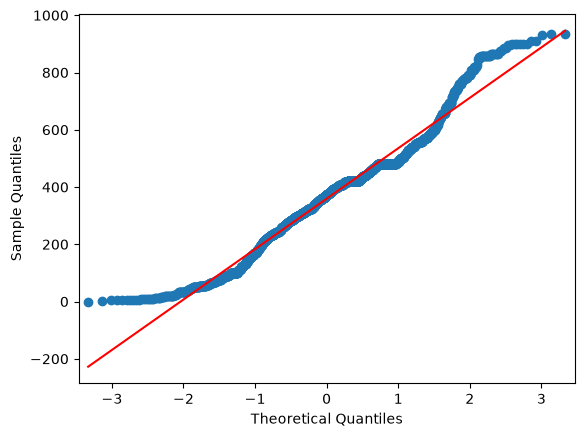

In [41]:
# We perform a qq plot then
sm.qqplot(df1d.x1, line="s")
pylab.show()

In [42]:
N = 200

In [43]:
# Cap the normality-test sample to the actual dataset size
N = min(N, df1d.shape[0])
df1d_sample = df1d.sample(N)

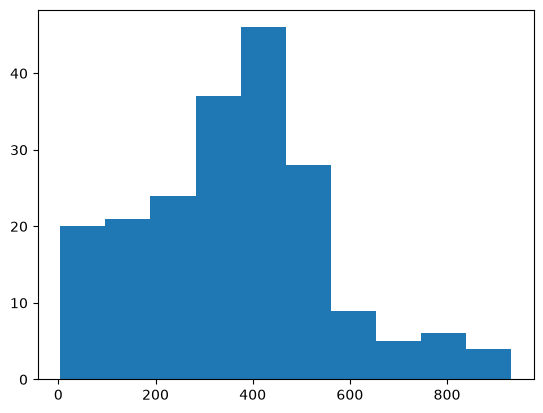

In [44]:
pyplot.hist(df1d_sample)
pyplot.show()

In [45]:
stats.shapiro(df1d_sample.x1)

ShapiroResult(statistic=np.float64(0.9709890747237062), pvalue=np.float64(0.00037448092156406427))

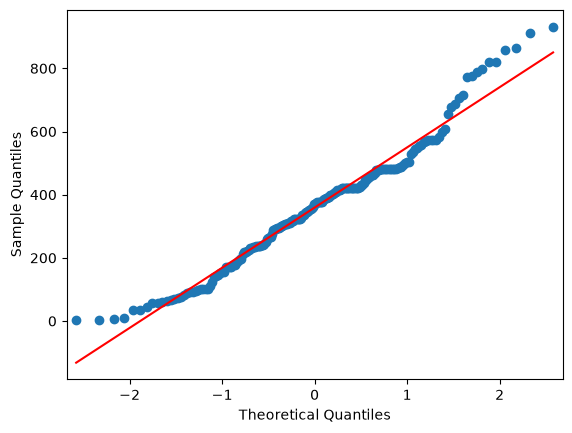

In [46]:
# We perform a qq plot then
sm.qqplot(df1d_sample.x1, line="s")
pylab.show()

In [47]:
# Henze-Zirkler Multivariate Normality Test
# multivariate_normality(df1d_sample)

## 2D 

In [48]:
df2d = dfs[1].rename(columns={"hw12": "x1", "hw23": "x2"}, inplace=False)
df2d = df2d[["x1", "x2"]]

In [49]:
# Cap the normality-test sample to the actual dataset size
N = min(N, df2d.shape[0])
df2d_sample = df2d.sample(N)

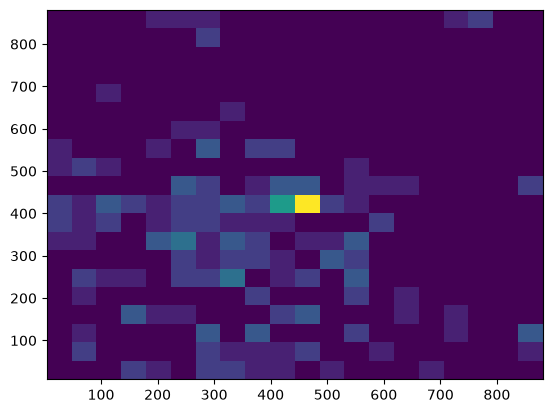

In [50]:
pyplot.hist2d(df2d_sample.x1, df2d_sample.x2, bins=20)
pyplot.show()

In [51]:
# Henze-Zirkler Multivariate Normality Test
multivariate_normality(df2d_sample)

HZResults(hz=np.float64(131.0086153598728), pval=np.float64(2.784237889513443e-62), normal=False)

In [52]:
from scipy.stats import pearsonr

corr, _ = pearsonr(df2d_sample.x1, df2d_sample.x2)
print(f"Pearsons correlation: {corr:.3f}")

Pearsons correlation: -0.074


## 3D

In [53]:
df3d = dfs[2].rename(columns={"hw12": "x1", "hw23": "x2", "hw34": "x3"}, inplace=False)
df3d = df3d[["x1", "x2", "x3"]]

In [54]:
# Cap sample to actual data size
N = min(N, df3d.shape[0])
df3d_sample = df3d.sample(N)
df3d_sample

,x1,x2,x3
1663,315,6,437
460,355,291,101
199,101,695,33
1394,232,197,299
742,228,464,167
...,...,...,...
1135,151,385,260
814,298,345,345
706,344,658,480
1426,408,337,238


In [55]:
# Henze-Zirkler Multivariate Normality Test
multivariate_normality(df3d_sample)

HZResults(hz=np.float64(155.56430911097456), pval=np.float64(4.3207431241384625e-187), normal=False)

## Cross-validation Results

In [56]:
n_folds = 3
results = cross_validate(n_folds, dfs)

In [57]:
results[(results.dim == 2) & (results.conf == 0.95)]

,dim,fold,n_slices,conf,size_th,anoms_detected,mean_size,max_size,min_size,anom_percent
30,2,1/3,708,0.95,1,9,7.333,30,1,9.322
31,2,1/3,708,0.95,2,7,9.143,30,2,9.040
32,2,1/3,708,0.95,3,6,10.333,30,3,8.757
39,2,2/3,708,0.95,1,8,8.500,14,3,9.605
40,2,2/3,708,0.95,2,8,8.500,14,3,9.605
41,2,2/3,708,0.95,3,8,8.500,14,3,9.605
48,2,3/3,708,0.95,1,5,1.800,3,1,1.271
49,2,3/3,708,0.95,2,2,3.000,3,3,0.847
50,2,3/3,708,0.95,3,2,3.000,3,3,0.847


In [58]:
def joint_cross_validation_results(cv_results, dim):
    cv_results = cv_results[cv_results.dim == dim]
    confs = cv_results.conf.unique()
    size_ths = cv_results.size_th.unique()

    rows = []
    for conf in confs:
        for size_th in size_ths:
            cv_res_conf = cv_results[(cv_results.conf == conf) & (cv_results.size_th == size_th)]

            n_slices = cv_res_conf.n_slices.sum()
            anoms_det = cv_res_conf.anoms_detected.sum()
            mean_size = cv_res_conf.mean_size.mean()
            max_size = cv_res_conf.max_size.max()
            anom_percent = mean_size * anoms_det * 100 / n_slices

            row = {}
            row["dim"] = dim
            row["folds"] = cv_res_conf.shape[0]
            row["n_slices"] = cv_res_conf.n_slices.sum()
            row["conf"] = conf
            row["size_th"] = size_th
            row["anoms_detected"] = anoms_det
            row["mean_size"] = mean_size
            row["max_size"] = max_size
            row["anom_percent"] = anom_percent

            rows.append(row)

    return pd.DataFrame(rows)

In [59]:
joint_cross_validation_results(results, 1)

,dim,folds,n_slices,conf,size_th,anoms_detected,mean_size,max_size,anom_percent
0,1,3,2310,0.90,1,52,4.983,30,11.216
1,1,3,2310,0.90,2,38,5.833,30,9.596
2,1,3,2310,0.90,3,27,7.246,30,8.469
3,1,3,2310,0.95,1,22,4.730,30,4.505
4,1,3,2310,0.95,2,18,5.689,30,4.433
5,1,3,2310,0.95,3,12,7.667,30,3.983
6,1,3,2310,0.99,1,7,6.000,19,1.818
7,1,3,2310,0.99,2,6,7.056,19,1.833
8,1,3,2310,0.99,3,5,9.889,19,2.140


## Train Models Parameters

In [60]:
# Get models parameters
cov_matrixes, means = get_model_params(dfs[0:3])

In [61]:
cov_matrixes

[np.float64(176.1980263909763),
 array([[32839.50048876, -4547.59857095],
        [-4547.59857095, 30116.73662346]]),
 array([[33103.7079639 , -6031.16246632,  4846.02177455],
        [-6031.16246632, 32016.63916374, -5382.8309242 ],
        [ 4846.02177455, -5382.8309242 , 28834.04391314]])]

In [62]:
# Test models built performance

# HYPERPARAMETERS
# Number of consecutive values over Mahalanobis distance to consider we have an outlier
size_ths = [1, 2, 3]
# Confidence for each dimension
confs = [0.9, 0.95, 0.99]

# Run tests
results, anomalies_dfs = get_result(dfs[1], cov_matrixes, means, confs, size_ths)

In [63]:
# results[(results.dim.isin([2]))].drop(['min_size'],axis=1)

## 2D Test Results

In [64]:
# Represent anomalies with confidence ellipse (for 2D)
conf = 0.95
dim = 2
size_th = 1

In [65]:
# Extract the 2D anomalies for the selected hyperparameters
anomalies_2d_df = anomalies_dfs[conf][dim][size_th]

if anomalies_2d_df.shape[0] < 1:
    print(
        "No 2D anomalies detected for conf =",
        conf,
        "| size_th =",
        size_th,
        "in the current telemetry window.",
    )
else:
    max_anom_size = anomalies_2d_df.anom_size.max()
    anoms_detected = anomalies_2d_df.anom_index.max() + 1
    mean_size = round(anomalies_2d_df.drop_duplicates("anom_index").anom_size.mean(), 3)

In [66]:
from branca.colormap import linear

max_anom_size = max_anom_size if "max_anom_size" in dir() and max_anom_size > 0 else 1
colormap = linear.Reds_09.scale(-10, max_anom_size).to_step(max_anom_size + 12)
colormap

In [67]:
# anomalies_2d_df.tail()

In [68]:
# Get a reduced sample of the data
data = dfs[1].sample(frac=1)

In [69]:
x, y = ellipse(means[1], cov_matrixes[1], conf)

In [70]:
# Create figure
fig = go.Figure()

"""
#Plot trace
fig.add_trace(go.Scatter(
    showlegend=False,
    x = data.hw12,
    y = data.hw23,
    mode = 'markers',
    marker = dict(
        color='blue',
        size=2
    )
))
"""

# Select buses group to see over time
for i in range(1, max_anom_size):
    # Get series data
    anom_size_df = anomalies_2d_df.loc[anomalies_2d_df.anom_size == i]
    color = colormap(i)[0:7]
    k = 0
    for anom_index in anom_size_df.anom_index.unique().tolist():
        anom_df = anom_size_df.loc[anom_size_df.anom_index == anom_index]
        # Plot trace
        fig.add_trace(
            go.Scatter(
                name=f"Anomaly of size = {i}",
                showlegend=True if k == 0 else False,
                x=anom_df.hw12,
                y=anom_df.hw23,
                mode="lines+markers",
                line={"color": color, "width": 1.5},
                text=anom_df.datetime.dt.time,
            )
        )
        k += 1


# Confidence ellipses
i = 0
for conf in [0.95]:
    x, y = ellipse(means[1], cov_matrixes[1], conf)
    fig.add_trace(
        go.Scatter(
            name=f"{conf * 100}% Confidence Ellipse",
            x=x,
            y=y,
            mode="lines",
            line={"color": colors[i], "width": 1.5},
        )
    )
    i += 1


# Update the layout
fig.update_layout(
    title=f"2D Headways inside line {line}, in {day_type} days from {st_hour}:00 to {end_hour}:00.",
    height=800,
    width=800,
    showlegend=False,
    legend={
        "x": 0.75,
        "y": 0.99,
        "traceorder": "normal",
        "font": {"size": 12},
    },
    xaxis={"title": "hw12", "nticks": 20, "zerolinecolor": "darkgrey"},
    yaxis={
        "title": "hw23",
        "scaleanchor": "x",
        "scaleratio": 1,
        "nticks": 20,
        "zerolinecolor": "darkgrey",
    },
)
fig.show()

## 2D Time series

In [71]:
# Pick a stable 2D analysis window (dim-2 slice)
index = 125
hws_2d = dfs[1][index : index + 500] if len(dfs) > 1 and dfs[1].shape[0] > 700 else dfs[1].head(500)
hws_2d[0:20]

,datetime,bus1,bus2,bus3,hw12,hw23
125,2026-08-18 10:56:27.773897,SK20AZJ,SK20BBX,SK20BDY,530,322
126,2026-08-18 10:56:27.773897,SK20BBX,SK20BDY,SK20AYU,322,407
127,2026-08-18 10:56:27.773897,SK20BDY,SK20AYU,SK20AYG,407,480
128,2026-08-18 10:55:47.469685,SK20AYV,SK20AXW,SK20BDV,283,347
129,2026-08-18 10:55:47.469685,SK20AXY,SK20BBE,SK20AYA,769,101
130,2026-08-18 10:55:47.469685,SK20AXW,SK20BDV,SK20AYS,347,72
131,2026-08-18 10:55:47.469685,SK20BBE,SK20AYA,SK20BDO,101,686
132,2026-08-18 10:55:47.469685,SK20BDV,SK20AYS,SK20AXV,72,478
133,2026-08-18 10:55:47.469685,SK20AYA,SK20BDO,SK20BCE,686,9
134,2026-08-18 10:55:47.469685,SK20AYS,SK20AXV,SK20AYW,478,220


In [72]:
busA_1 = hws_2d.iloc[index].bus1
busB_1 = hws_2d.iloc[index].bus2
busC_1 = hws_2d.iloc[index].bus3

busA_2 = hws_2d.iloc[index + 1].bus1
busB_2 = hws_2d.iloc[index + 1].bus2
busC_2 = hws_2d.iloc[index + 1].bus3

busA_3 = hws_2d.iloc[index + 2].bus1
busB_3 = hws_2d.iloc[index + 2].bus2
busC_3 = hws_2d.iloc[index + 2].bus3

busA_4 = hws_2d.iloc[index + 3].bus1
busB_4 = hws_2d.iloc[index + 3].bus2
busC_4 = hws_2d.iloc[index + 3].bus3


# b1,b2,b3,b4,b5 = 119,118,8238,116,121

# hw_AB1 = hws.loc[(hws.busA==b1)&(hws.busB==b2)]
# hw_AB2 = hws.loc[(hws.busA==b2)&(hws.busB==b3)]
# hw_AB3 = hws.loc[(hws.busA==b3)&(hws.busB==b4)]

# hw_AB4 = hws.loc[(hws.busA==b4)&(hws.busB==b5)]
# hw_AB5 = hws.loc[(hws.busA==b3)&(hws.busB==b2)]

hw_ABC1 = hws_2d.loc[(hws_2d.bus1 == busA_1) & (hws_2d.bus2 == busB_1) & (hws_2d.bus3 == busC_1)]
hw_ABC2 = hws_2d.loc[(hws_2d.bus1 == busA_2) & (hws_2d.bus2 == busB_2) & (hws_2d.bus3 == busC_2)]
hw_ABC3 = hws_2d.loc[(hws_2d.bus1 == busA_3) & (hws_2d.bus2 == busB_3) & (hws_2d.bus3 == busC_3)]
hw_ABC4 = hws_2d.loc[(hws_2d.bus1 == busA_4) & (hws_2d.bus2 == busB_4) & (hws_2d.bus3 == busC_4)]

hw_ABC1.iloc[0:10]

,datetime,bus1,bus2,bus3,hw12,hw23
140,2026-08-18 10:55:47.469685,SK20BBU,SK20AYJ,SK20BDU,237,484
162,2026-08-18 10:55:07.082799,SK20BBU,SK20AYJ,SK20BDU,237,484
184,2026-08-18 10:54:26.594006,SK20BBU,SK20AYJ,SK20BDU,276,443
206,2026-08-18 10:53:46.167159,SK20BBU,SK20AYJ,SK20BDU,276,443
228,2026-08-18 10:53:05.670491,SK20BBU,SK20AYJ,SK20BDU,276,443
250,2026-08-18 10:52:25.044504,SK20BBU,SK20AYJ,SK20BDU,323,411
272,2026-08-18 10:51:44.718785,SK20BBU,SK20AYJ,SK20BDU,323,411
294,2026-08-18 10:51:04.143596,SK20BBU,SK20AYJ,SK20BDU,314,454
317,2026-08-18 10:50:23.795086,SK20BBU,SK20AYJ,SK20BDU,308,407
340,2026-08-18 10:49:43.417637,SK20BBU,SK20AYJ,SK20BDU,308,407


In [73]:
# Create figure
fig = go.Figure()

hw_ABCs = [hw_ABC1, hw_ABC2, hw_ABC3, hw_ABC4]
for k in range(len(hw_ABCs)):
    hw_ABC = hw_ABCs[k]
    # Separate fragments
    hw_ABC_splits = []
    last_index = 0
    last_time = hw_ABC.iloc[0].datetime
    nsplits = 0
    for i in range(hw_ABC.shape[0]):
        if ((hw_ABC.iloc[i].datetime - last_time).total_seconds() > 500) | (
            (i + 1) == hw_ABC.shape[0]
        ):
            split = hw_ABC.iloc[last_index:i]
            nsplits += 1
            if split.shape[0] < 1:
                continue
            last_index = i

            fig.add_trace(
                go.Scatter(
                    showlegend=False,
                    x=[split.hw12.iloc[-1]],
                    y=[split.hw23.iloc[-1]],
                    mode="markers",
                    marker={"color": "black", "size": 10},
                )
            )

            fig.add_trace(
                go.Scatter(
                    name=f"{split.iloc[0].bus1}-{split.iloc[0].bus2}-{split.iloc[0].bus3}",
                    showlegend=(nsplits == 1),
                    x=split.hw12,
                    y=split.hw23,
                    mode="lines+markers",
                    line={"color": colors[k], "width": 1.5},
                )
            )

        last_time = hw_ABC.iloc[i].datetime

# Update the layout
fig.update_layout(
    height=800,
    width=800,
    legend={
        "title": "<b>Buses group",
        "x": 0.7,
        "y": 0.99,
        "traceorder": "normal",
        "font": {"size": 12},
    },
    xaxis={"title": "hw12", "nticks": 20, "zerolinecolor": "darkgrey"},
    yaxis={
        "title": "hw23",
        "scaleanchor": "x",
        "scaleratio": 1,
        "nticks": 20,
        "zerolinecolor": "darkgrey",
    },
)
fig.show()

## Get data outside confidence region

In [74]:
# Get Mahalanobis distance squared from which a certain percentage of the data is out
m_th = math.sqrt(chi2.ppf(conf, df=dim))
m_th

2.447746830680816

In [75]:
data.head()

,datetime,bus1,bus2,bus3,hw12,hw23
1868,2026-08-18 10:06:28.120185,SK20AXV,SK20AYW,SK20BBU,265,422
888,2026-08-18 10:34:49.248752,SK20BDU,SK20AYN,SK20BBX,245,848
1473,2026-08-18 10:16:26.093317,SK20BCE,SK20BDO,SK20AZC,531,420
1318,2026-08-18 10:20:29.270652,SK20AYZ,SK20BCZ,SK20BDE,135,376
587,2026-08-18 10:42:58.171411,SK20BBU,SK20AYJ,SK20BDU,295,553


In [76]:
# Calculate mahalanobis distance for each point of the group
m_dists = []
hw_names = ["hw" + str(i) + str(i + 1) for i in range(1, dim + 1)]
mean = means[dim - 1]
cov_matrix = cov_matrixes[dim - 1]
# Inverse of cov matrix
if dim > 1:
    iv = np.linalg.inv(cov_matrix)
else:
    std = cov_matrix

for i in range(data.shape[0]):
    hws = data.iloc[i][hw_names]
    if dim > 1:
        m_dist = mahalanobis(mean, hws, iv)
    else:
        std = cov_matrix
        hw_val = hws.iloc[0]
        m_dist = np.abs(mean - hw_val) / std
    m_dists.append(m_dist)

In [77]:
data["m_dist"] = m_dists

In [78]:
# Remove instances inside confidence region
data = data[data.m_dist >= m_th]

In [79]:
# Create figure
fig = go.Figure()

# Plot trace
fig.add_trace(
    go.Scatter(
        showlegend=False,
        x=data.hw12,
        y=data.hw23,
        mode="markers",
        marker={"color": "blue", "size": 1},
    )
)

"""
#Select buses group to see over time
for i in range(1,max_anom_size) :
    #Get series data
    anom_size_df = anomalies_2d_df.loc[anomalies_2d_df.anom_size == i]
    color = colormap(i)[0:7]
    k = 0
    for anom_index in anom_size_df.anom_index.unique().tolist() :
        anom_df = anom_size_df.loc[anom_size_df.anom_index == anom_index]
        #Plot trace
        fig.add_trace(go.Scatter(
            name='Anomaly of size = {}'.format(i),
            showlegend= True if k==0 else False,
            x = anom_df.hw12,
            y = anom_df.hw23,
            mode = 'lines+markers',
            line = dict(
                color = color,
                width = 1.5
            ),
            text = anom_df.datetime.dt.time
        ))
        k+=1
"""


# Confidence ellipse
x, y = ellipse(means[1], cov_matrixes[1], conf)
fig.add_trace(
    go.Scatter(
        name=f"{conf * 100}% Confidence Ellipse",
        x=x,
        y=y,
        mode="lines",
        line={"color": colors[3], "width": 2.5},
    )
)


# Update the layout
fig.update_layout(
    title=f"2D Headways inside line {line}, in {day_type} days from {st_hour}:00 to {end_hour}:00. Points outside confidence region.",
    height=800,
    width=800,
    legend={
        "x": 0.75,
        "y": 0.99,
        "traceorder": "normal",
        "font": {"size": 12},
    },
    xaxis={"title": "hw12", "nticks": 20, "zerolinecolor": "darkgrey"},
    yaxis={
        "title": "hw23",
        "scaleanchor": "x",
        "scaleratio": 1,
        "nticks": 20,
        "zerolinecolor": "darkgrey",
    },
)
fig.show()

# Clustering

## Affinity Propagation

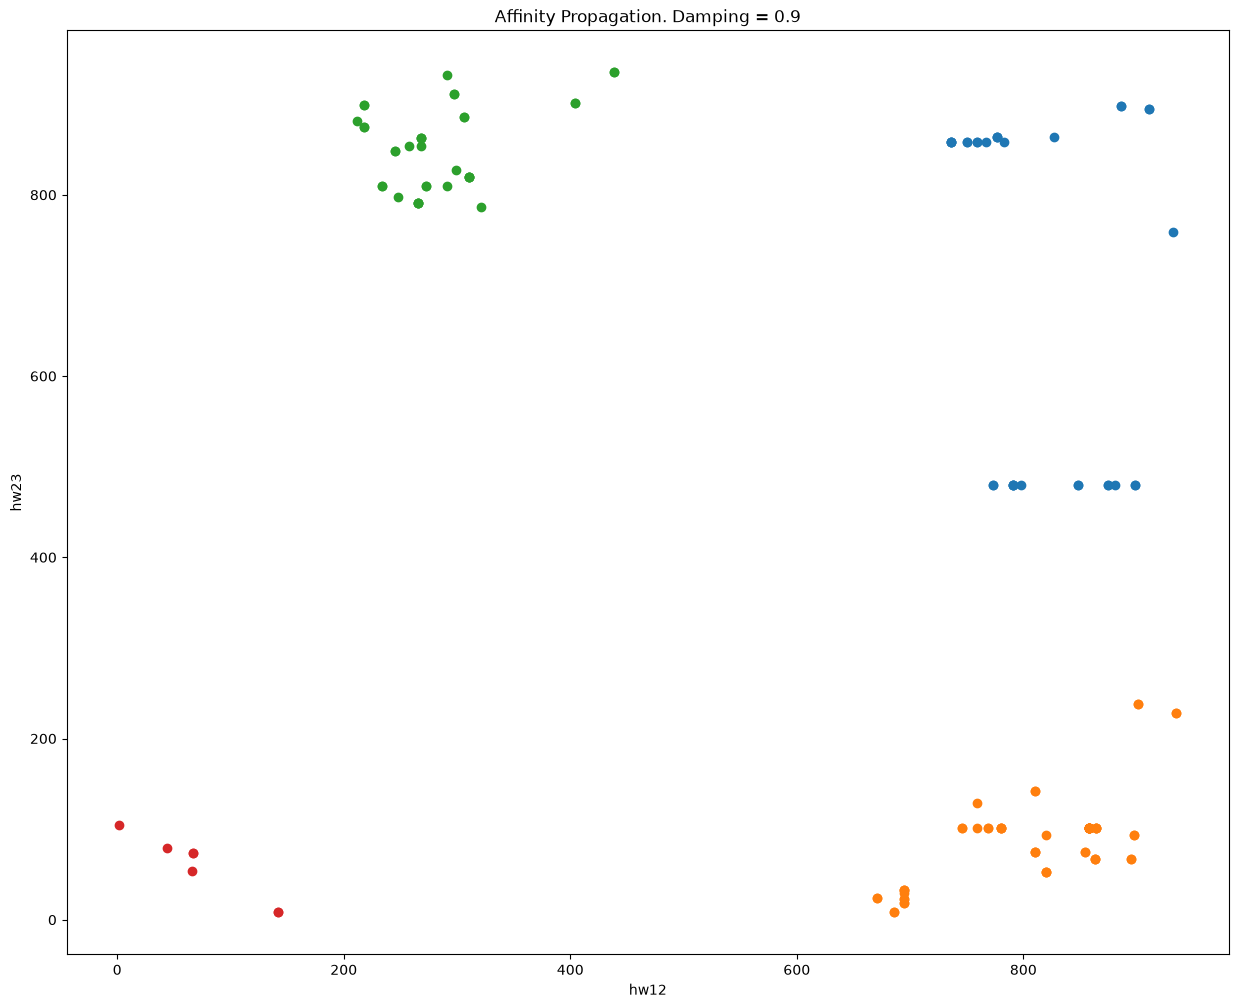

In [80]:
import matplotlib.pyplot as plt
from numpy import unique, where
from sklearn.cluster import AffinityPropagation

plt.figure(figsize=(15, 12))

# Data
features = data[["hw" + str(i) + str(i + 1) for i in range(1, 3)]]
X = features.values

# Model (guarded against empty telemetry windows)
damping = 0.9
if X.shape[0] >= 2:
    model = AffinityPropagation(damping=damping, random_state=None)

    # Fit the model
    model.fit(X)

    # Assign a cluster to each example
    yhat = model.predict(X)

    # Retrieve unique clusters and create plot
    clusters = unique(yhat)
    for cluster in clusters:
        row_ix = where(yhat == cluster)
        plt.scatter(X[row_ix, 0], X[row_ix, 1])
else:
    print("Not enough 2D headway points for AffinityPropagation clustering in this window.")

# Add title and axis names
plt.title(f"Affinity Propagation. Damping = {damping}")
plt.xlabel("hw12")
plt.ylabel("hw23")

# Show the plot
plt.show()

## DBSCAN

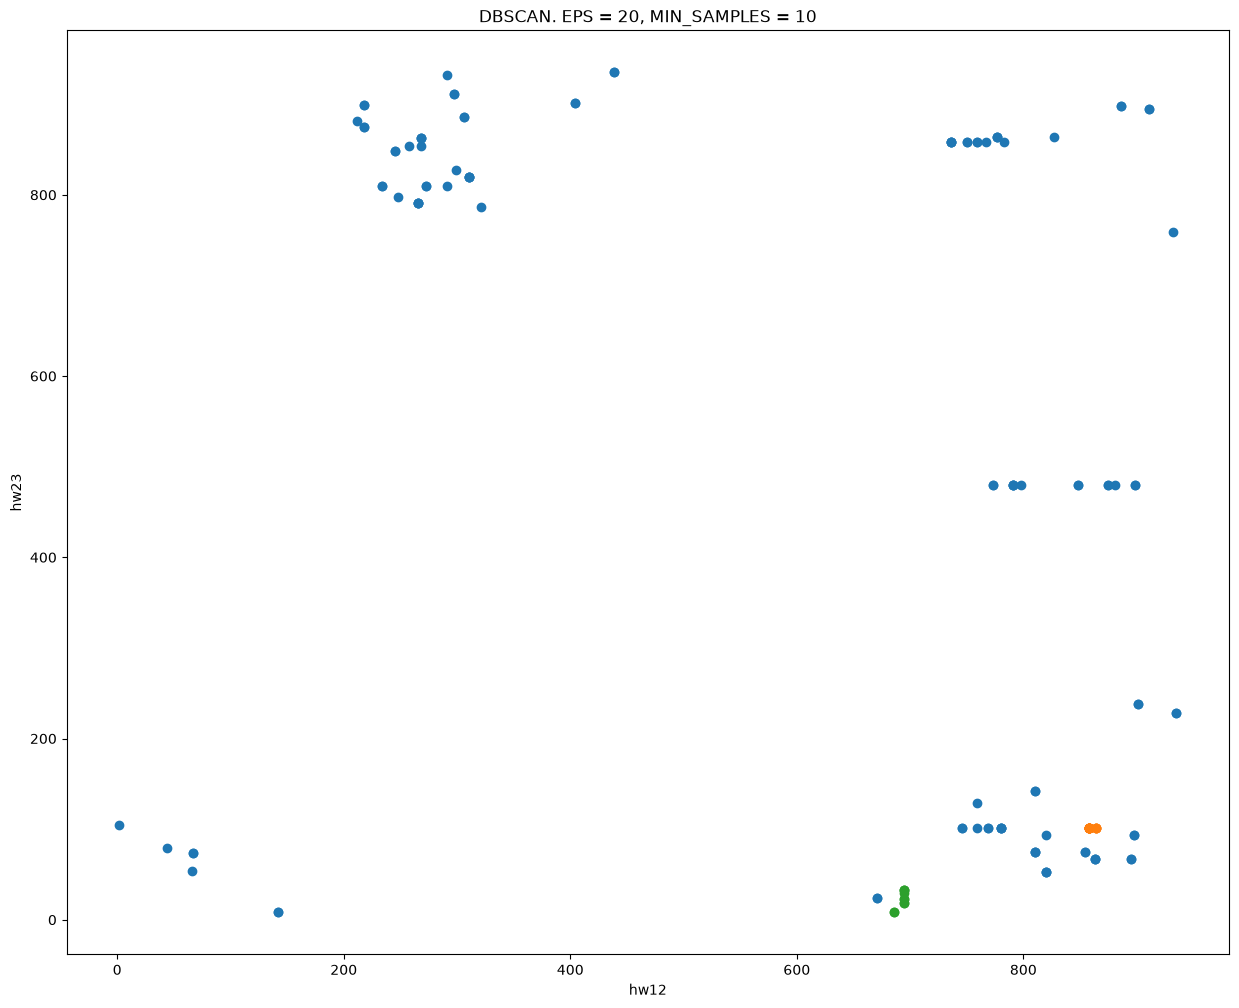

In [81]:
from sklearn.cluster import DBSCAN

plt.figure(figsize=(15, 12))

eps = 20
min_samples = 10

if X.shape[0] >= 1:
    model = DBSCAN(eps=eps, min_samples=min_samples)
    yhat = model.fit_predict(X)
    clusters = unique(yhat)
    for cluster in clusters:
        row_ix = where(yhat == cluster)
        plt.scatter(X[row_ix, 0], X[row_ix, 1])
else:
    print("Not enough 2D headway points for DBSCAN clustering in this window.")

# Add title and axis names
plt.title(f"DBSCAN. EPS = {eps}, MIN_SAMPLES = {min_samples}")
plt.xlabel("hw12")
plt.ylabel("hw23")

# Show the plot
plt.show()

## K-Means

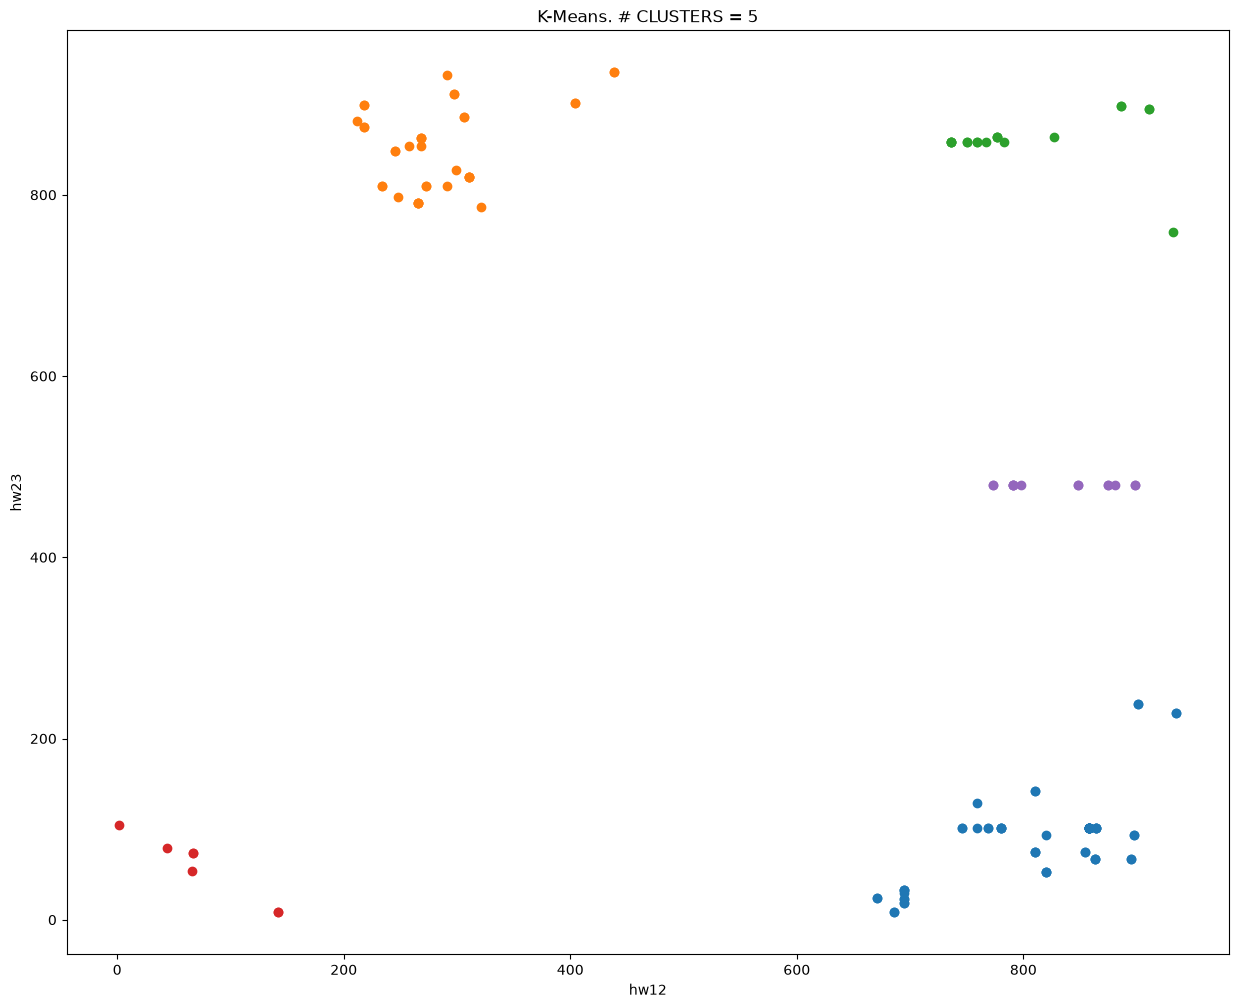

In [82]:
from sklearn.cluster import KMeans

plt.figure(figsize=(15, 12))

n_clusters = 5

if X.shape[0] >= 1:
    model = KMeans(n_clusters=n_clusters, n_init=10)
    model.fit(X)
    yhat = model.predict(X)

    clusters = unique(yhat)
    for cluster in clusters:
        row_ix = where(yhat == cluster)
        plt.scatter(X[row_ix, 0], X[row_ix, 1])
else:
    print("Not enough 2D headway points for K-Means clustering in this window.")

# Add title and axis names
plt.title(f"K-Means. # CLUSTERS = {n_clusters}")
plt.xlabel("hw12")
plt.ylabel("hw23")

# Show the plot
plt.show()

## Aglomerative Hierarchical Clustering

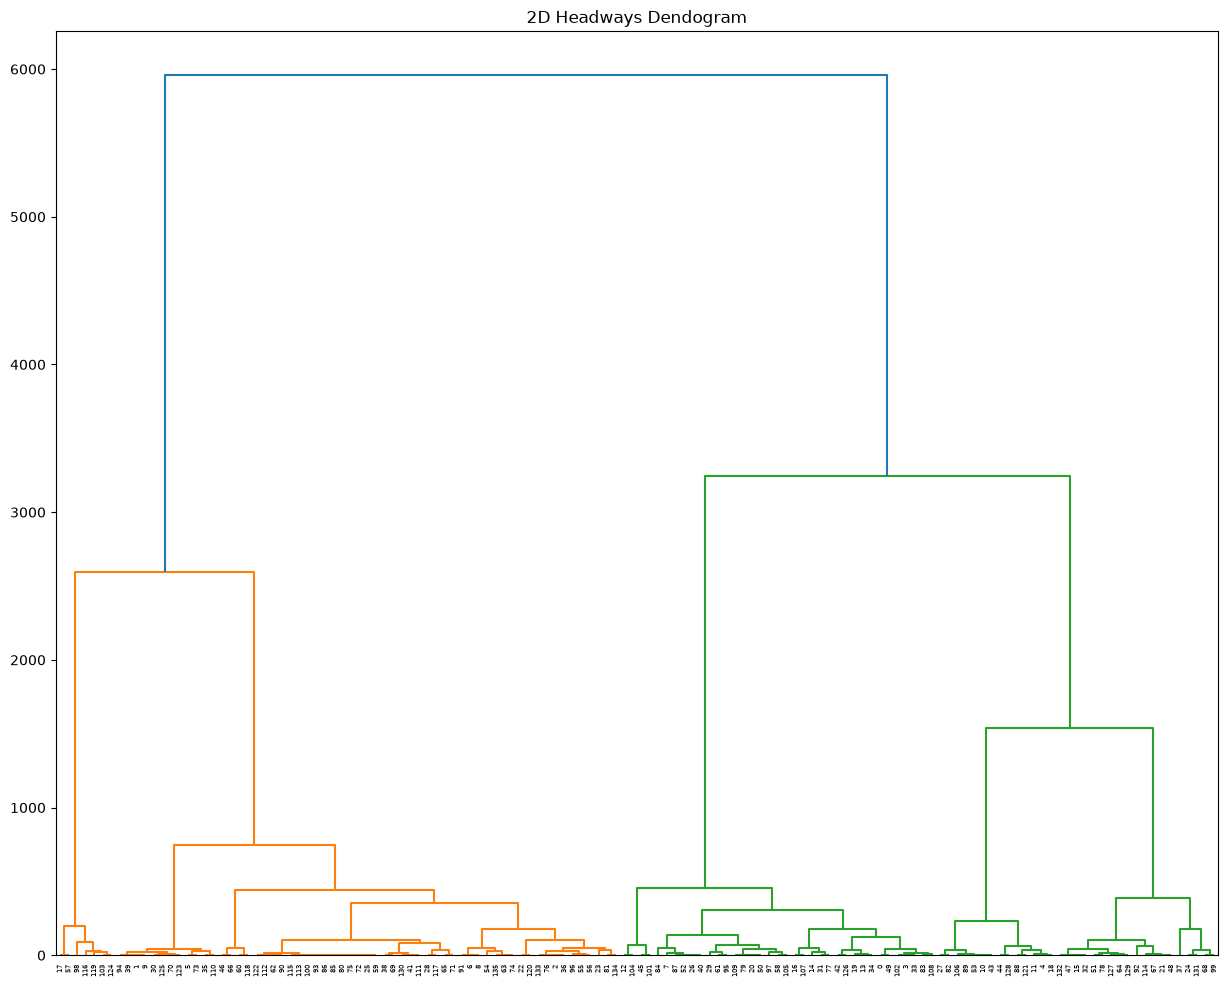

In [83]:
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering

plt.figure(figsize=(15, 12))
plt.title("2D Headways Dendogram")
if X.shape[0] >= 2:
    dend = shc.dendrogram(shc.linkage(X, method="ward"))
else:
    print("Not enough points for the dendrogram in this window.")

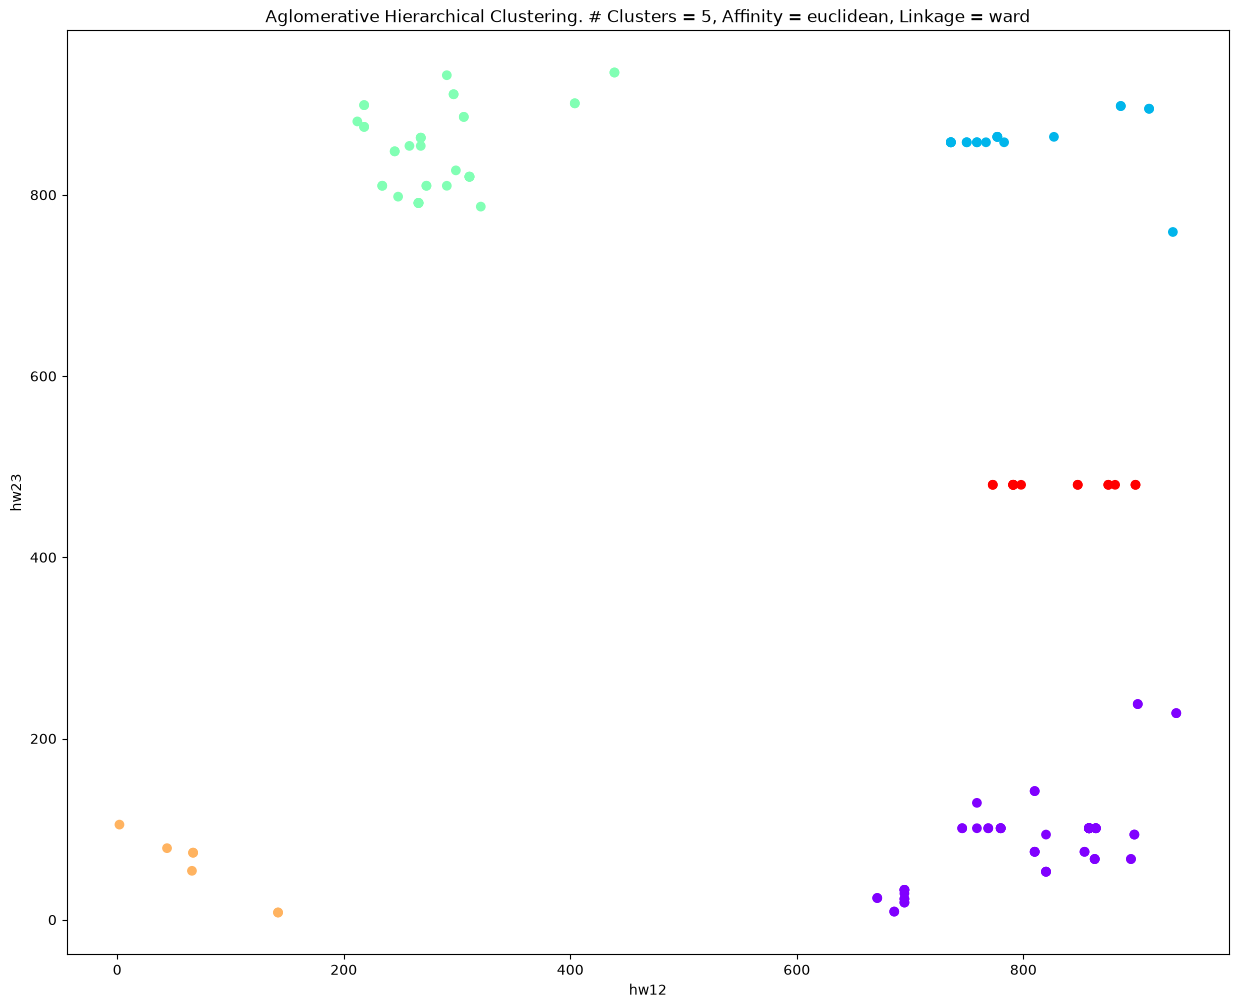

In [84]:
plt.figure(figsize=(15, 12))

n_clusters = 5
affinity = "euclidean"
linkage = "ward"

if X.shape[0] >= 1:
    cluster = AgglomerativeClustering(n_clusters=n_clusters, metric=affinity, linkage=linkage)
    cluster.fit_predict(X)
    plt.scatter(X[:, 0], X[:, 1], c=cluster.labels_, cmap="rainbow")
else:
    print("Not enough points for agglomerative clustering in this window.")

# Add title and axis names
plt.title(
    f"Aglomerative Hierarchical Clustering. # Clusters = {n_clusters}, Affinity = {affinity}, Linkage = {linkage}"
)
plt.xlabel("hw12")
plt.ylabel("hw23")
plt.show()

## Self-Organizing Maps

In [85]:
import simpsom as sps

net = sps.SOMNet(20, 20, X, PBC=True)
net.train(epochs=20000, start_learning_rate=0.01)

Periodic Boundary Conditions active.
The weights will be initialized with PCA.
The map will be trained with the batch algorithm.
Training SOM... 0% 

Training SOM... 1% 

Training SOM... 2% 

Training SOM... 3% 

Training SOM... 3% 

...

Training SOM... 96% 

Training SOM... 97% 

Training SOM... 98% 

Training SOM... 99% 

Training SOM... done!


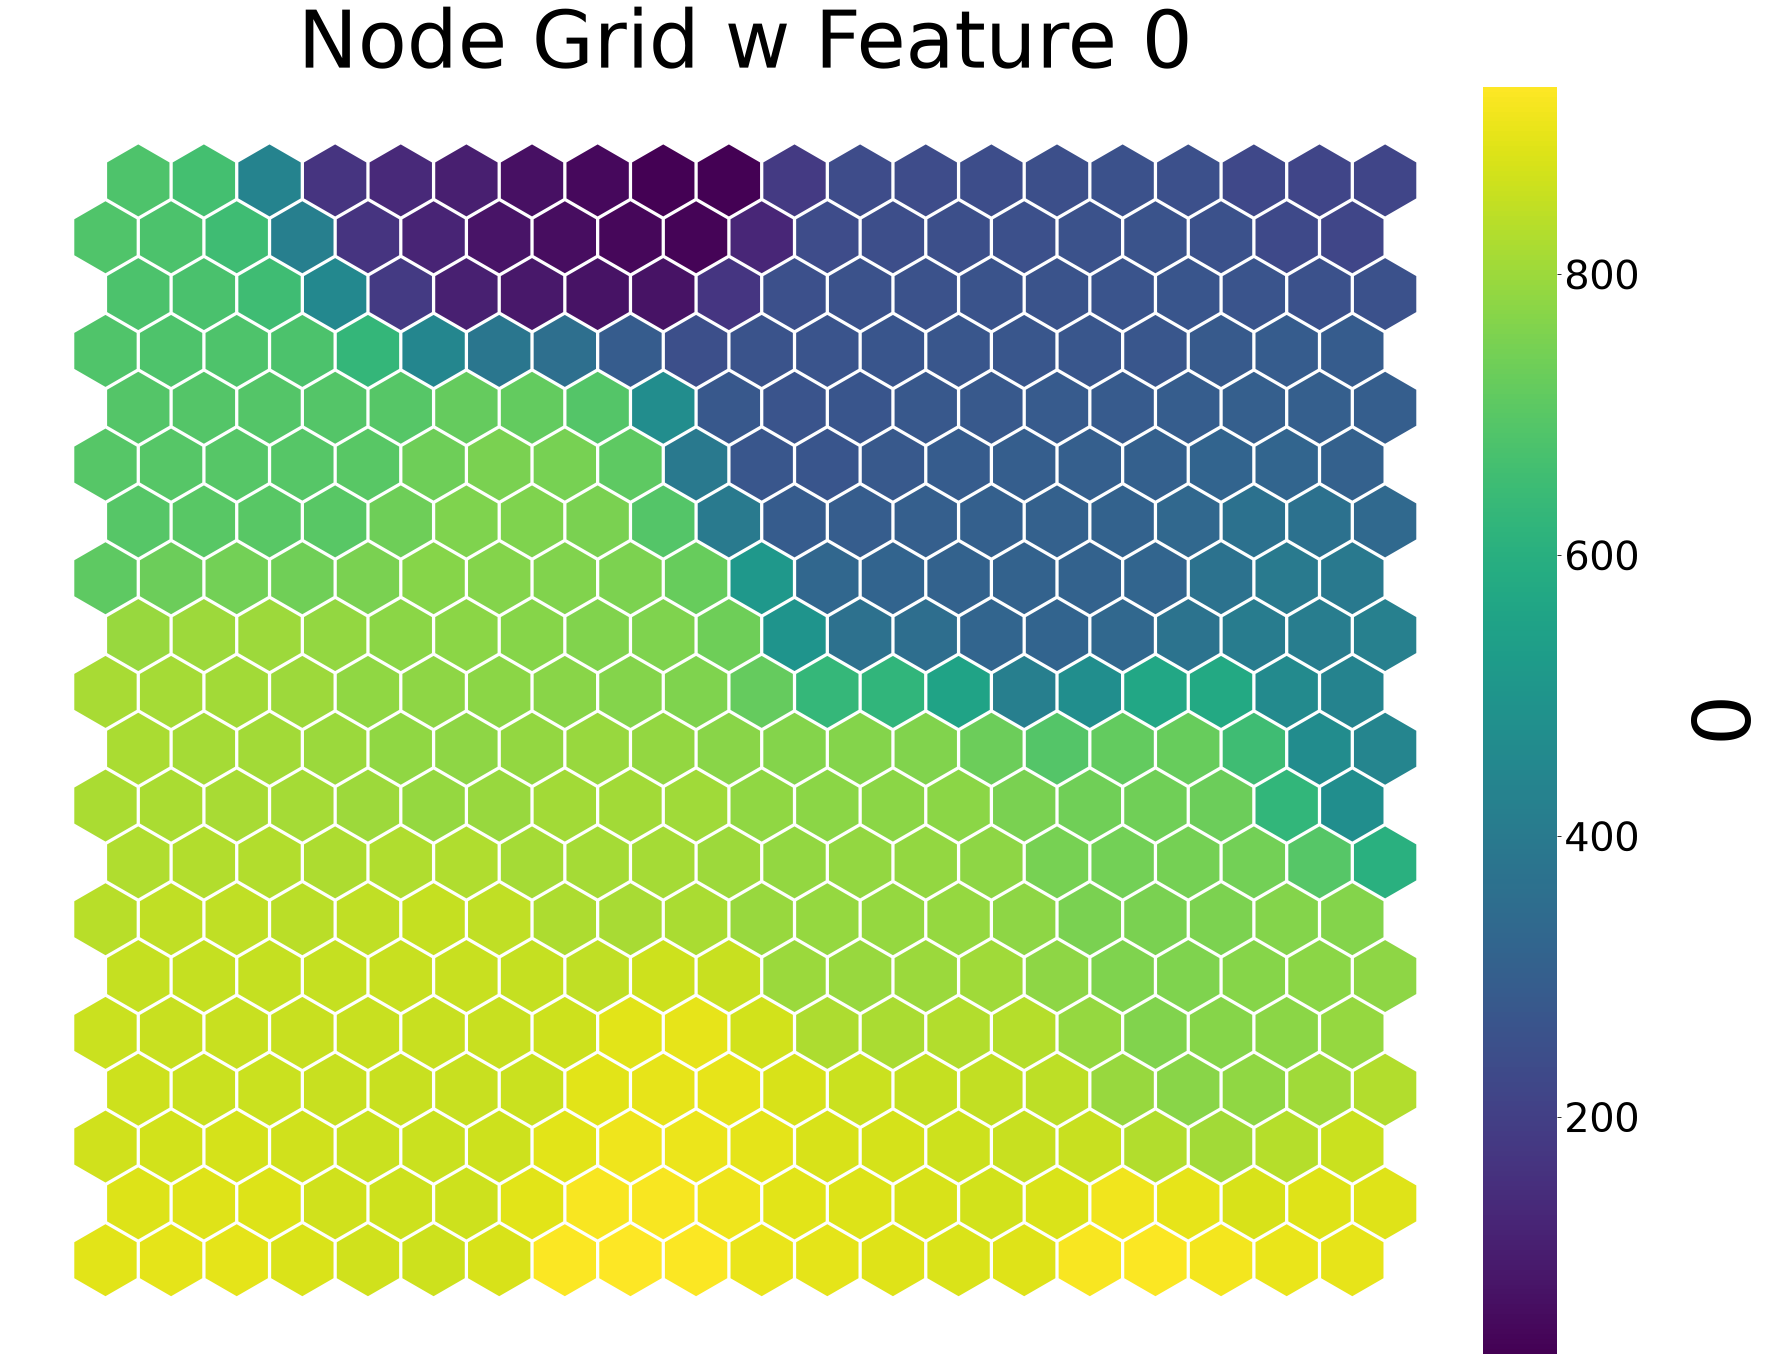

In [86]:
net.nodes_graph(colnum=0)

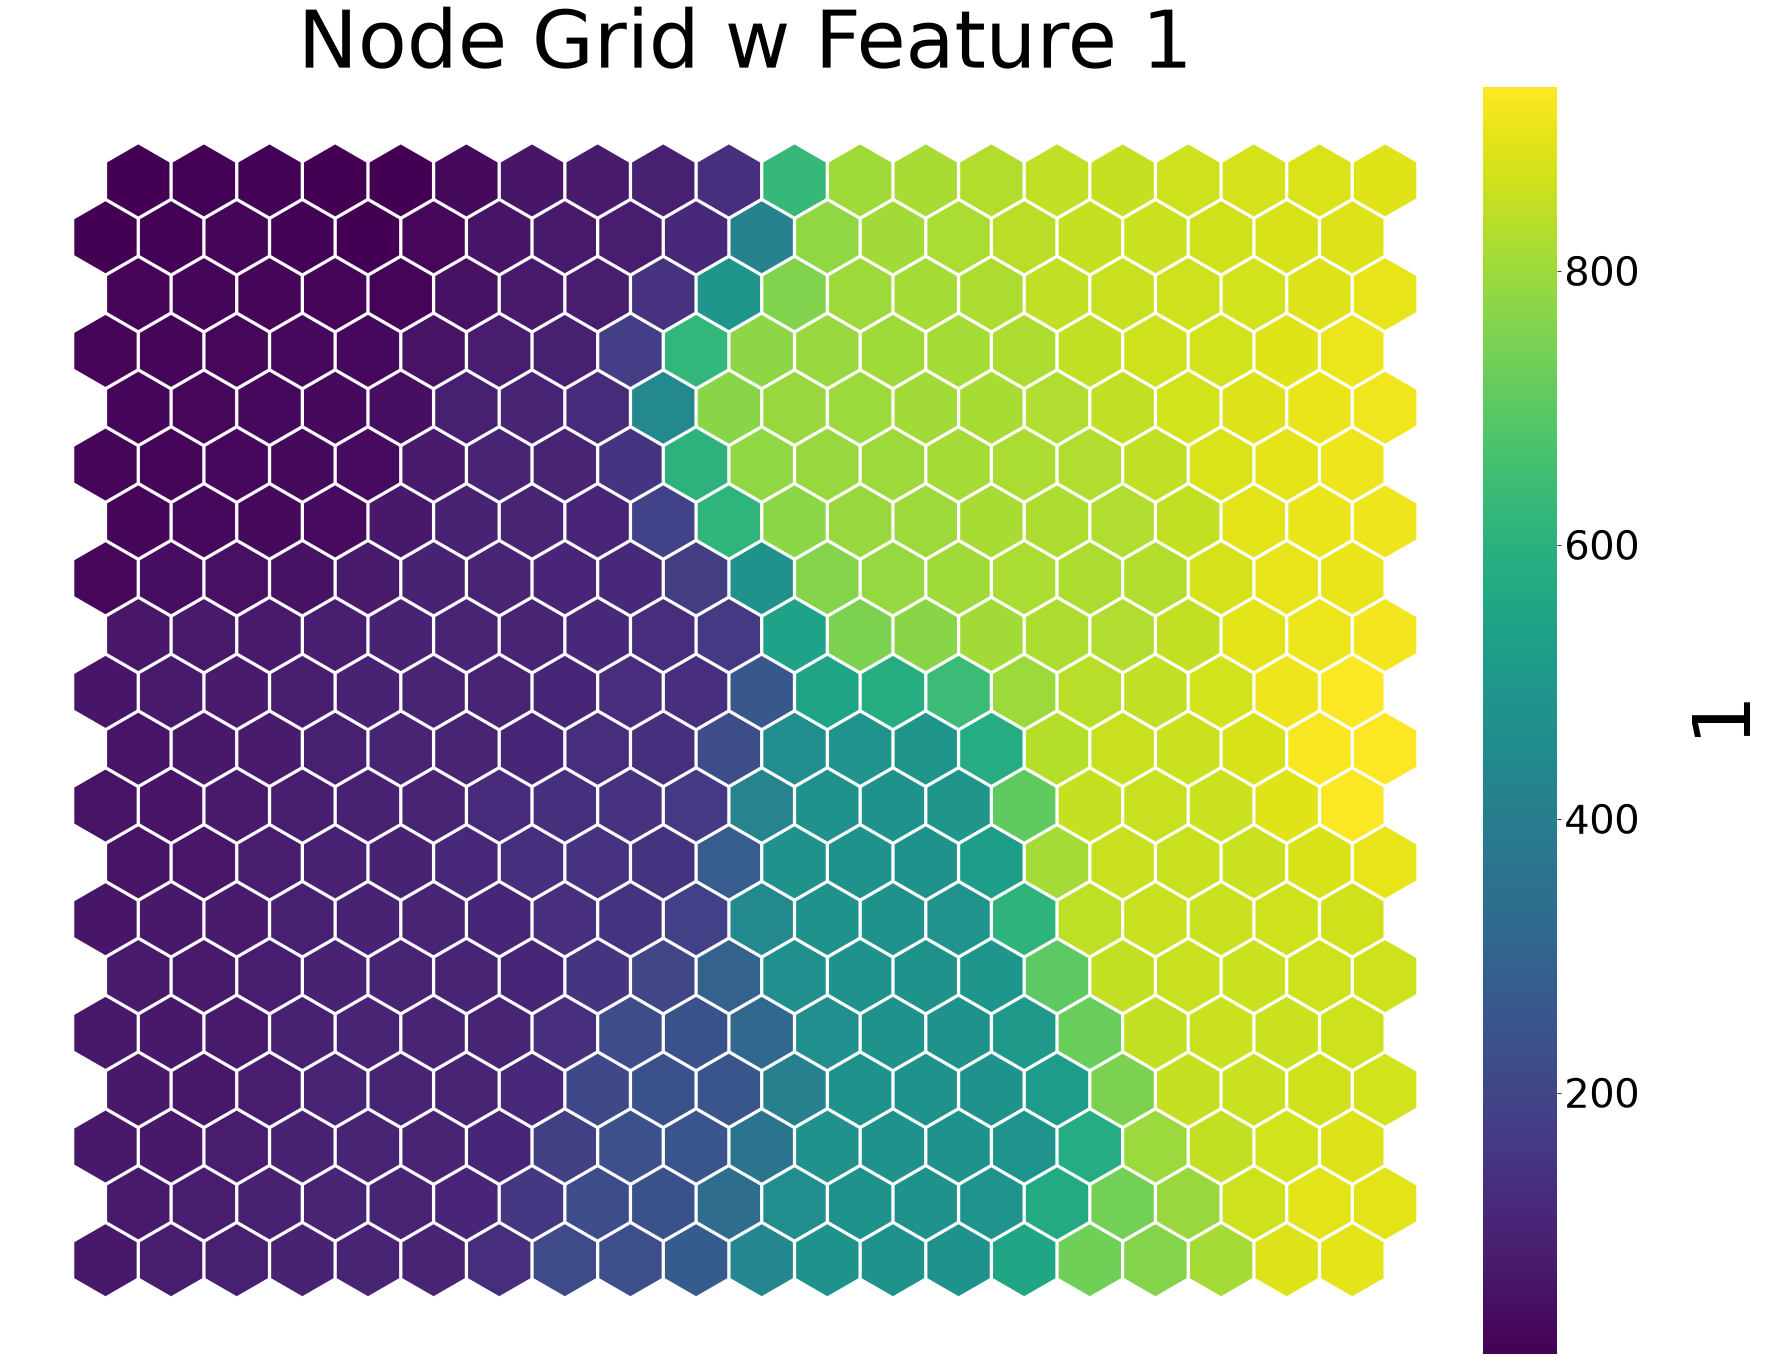

In [87]:
net.nodes_graph(colnum=1)

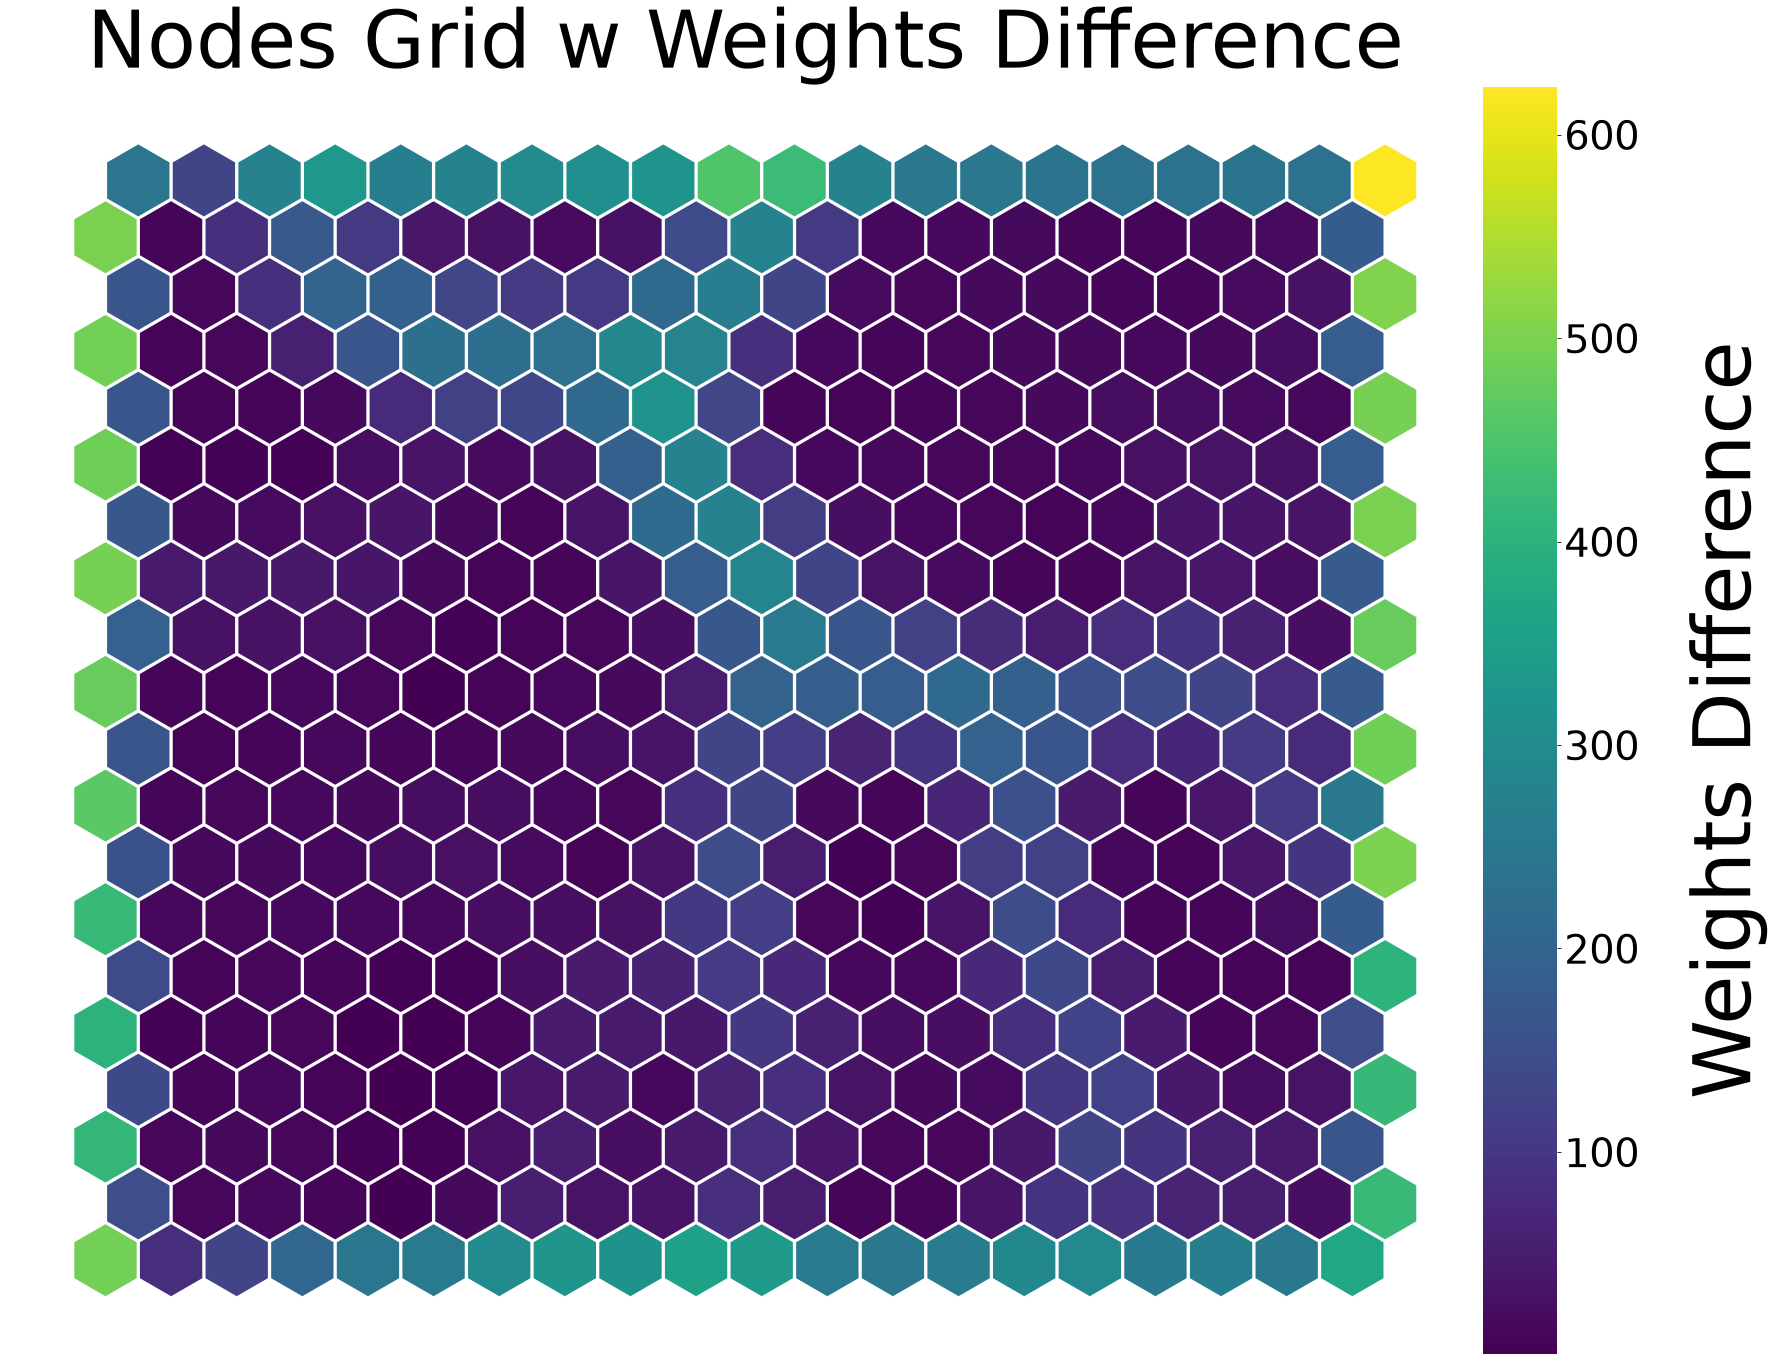

In [88]:
net.diff_graph()

/home/alejp1998/dev/theses/bus-headways-anom-detection/.venv/lib/python3.11/site-packages/simpsom/network.py:629: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter([pos[0]-0.125+random.random()*0.25 for pos in bmu_list],


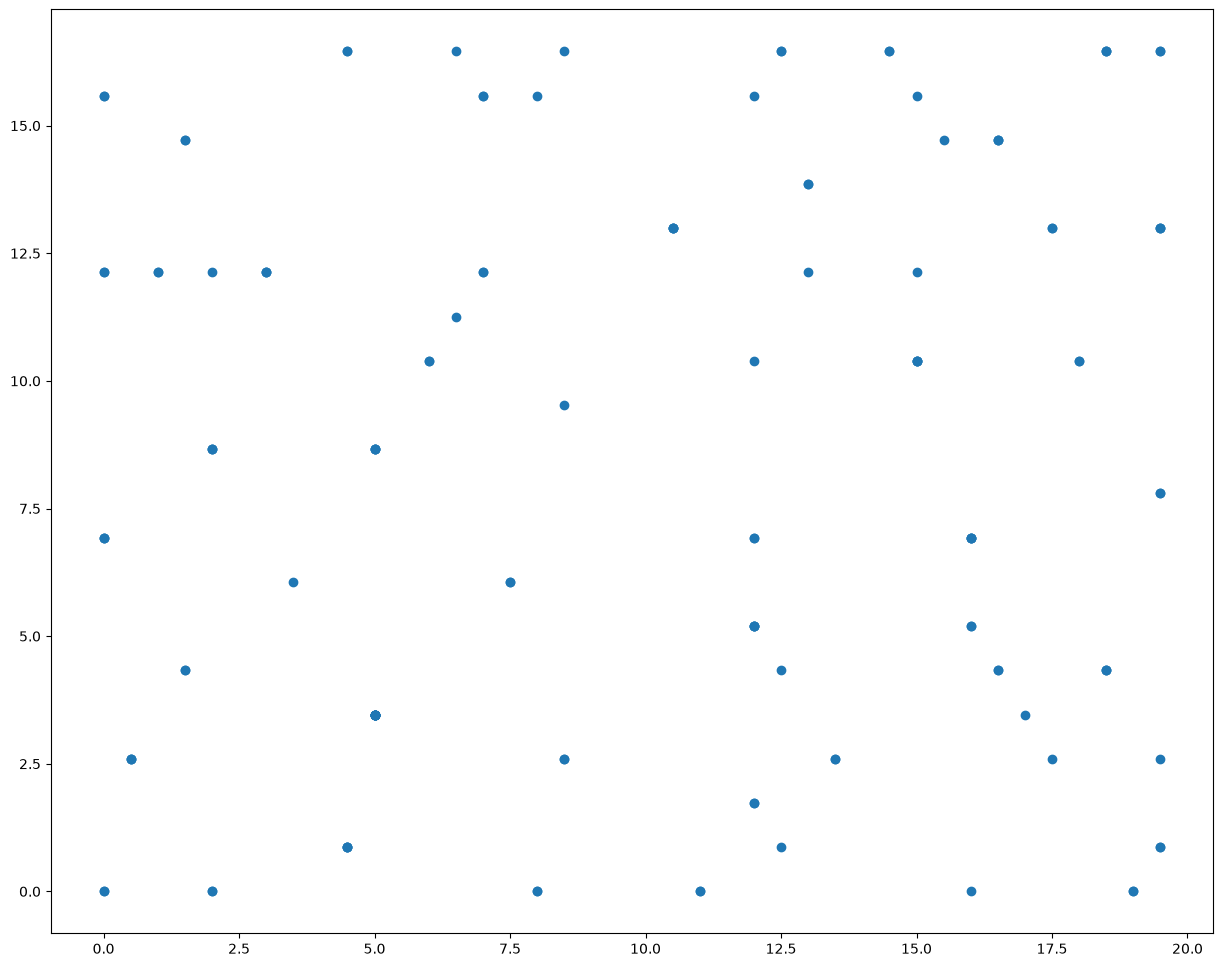

In [89]:
plt.figure(figsize=(15, 12))
prj = np.array(net.project(X))
plt.scatter(prj.T[0], prj.T[1])
plt.show()